# Get the Data

In [245]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_bike_sharing_data():
    return pd.read_csv(Path("datasets/bike+sharing+dataset/day.csv"))

bike_sharing_full = load_bike_sharing_data()

# Review the Data Structure

In [246]:
bike_sharing_full.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [247]:
bike_sharing_full = bike_sharing_full.set_index("instant")

In [248]:
bike_sharing_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 731 entries, 1 to 731
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      731 non-null    object 
 1   season      731 non-null    int64  
 2   yr          731 non-null    int64  
 3   mnth        731 non-null    int64  
 4   holiday     731 non-null    int64  
 5   weekday     731 non-null    int64  
 6   workingday  731 non-null    int64  
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  casual      731 non-null    int64  
 13  registered  731 non-null    int64  
 14  cnt         731 non-null    int64  
dtypes: float64(4), int64(10), object(1)
memory usage: 91.4+ KB


In [249]:
bike_sharing_full.describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [250]:
bike_sharing_full["holiday"].value_counts()

holiday
0    710
1     21
Name: count, dtype: int64

In [251]:
bike_sharing_full["season"].value_counts()

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

In [252]:
bike_sharing_full["weekday"].value_counts()

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64

In [253]:
bike_sharing_full["workingday"].value_counts()

workingday
1    500
0    231
Name: count, dtype: int64

In [254]:
bike_sharing_full["weathersit"].value_counts()

weathersit
1    463
2    247
3     21
Name: count, dtype: int64

In [255]:
bike_sharing_full["yr"].value_counts()

yr
1    366
0    365
Name: count, dtype: int64

In [256]:
bike_sharing_full["mnth"].value_counts()

mnth
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     57
Name: count, dtype: int64

In [257]:
bike_sharing_full = bike_sharing_full.drop(columns=["dteday"])
bike_sharing_full.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,,,,,,,,,,,,,,
1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [258]:
bike_sharing_full["casualRatio"] = bike_sharing_full["casual"] / bike_sharing_full["registered"]
bike_sharing_full.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,casualRatio
instant,,,,,,,,,,,,,,,
1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,0.506116
2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,0.195522
3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,0.097640
4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,0.074278
5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,0.054018


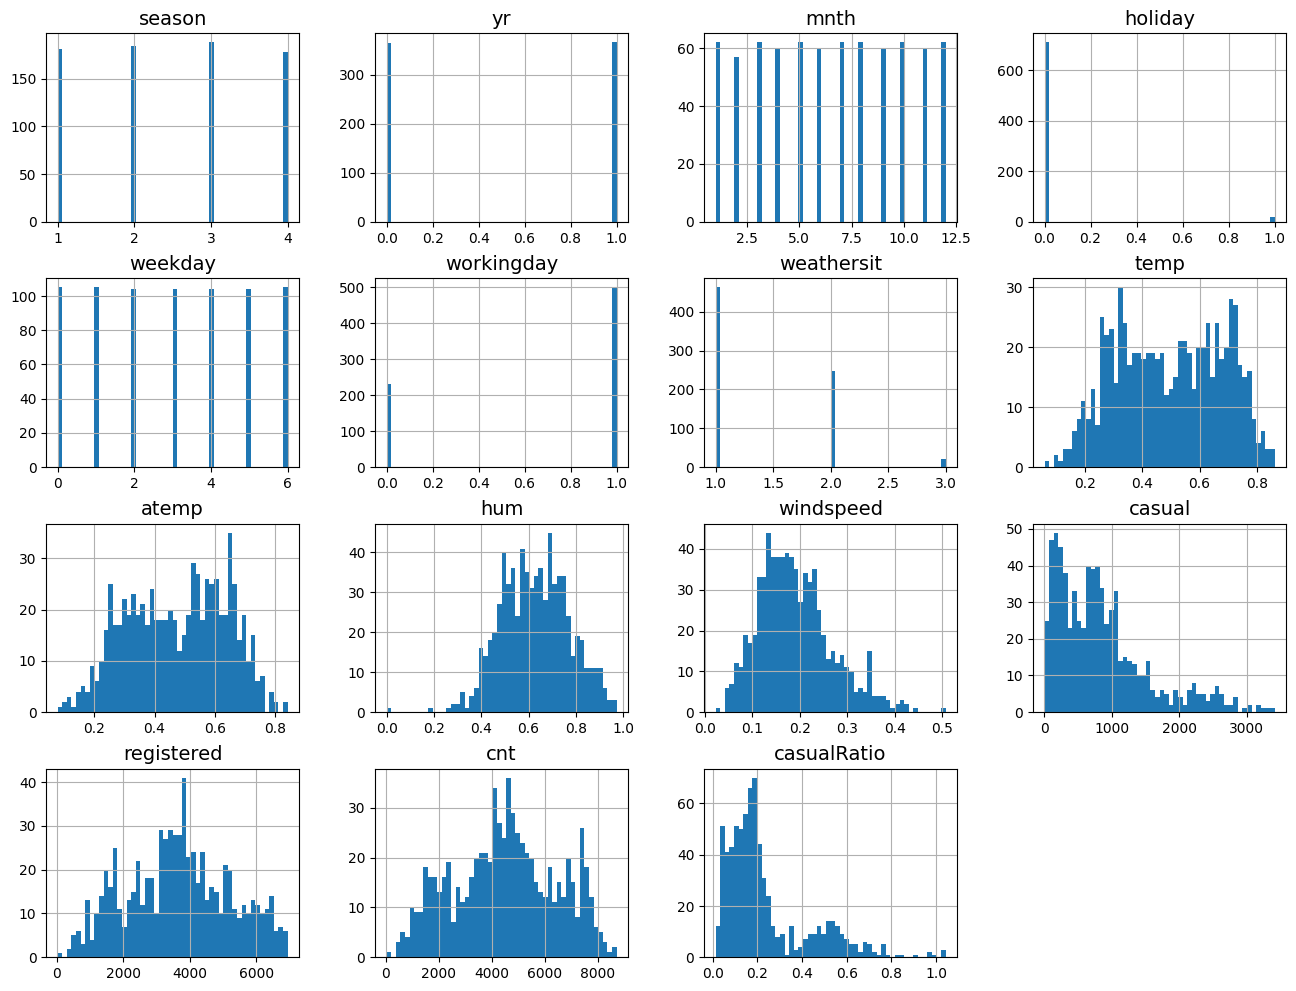

In [259]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

bike_sharing_full.hist(bins=50, figsize=(16, 12))

plt.show()

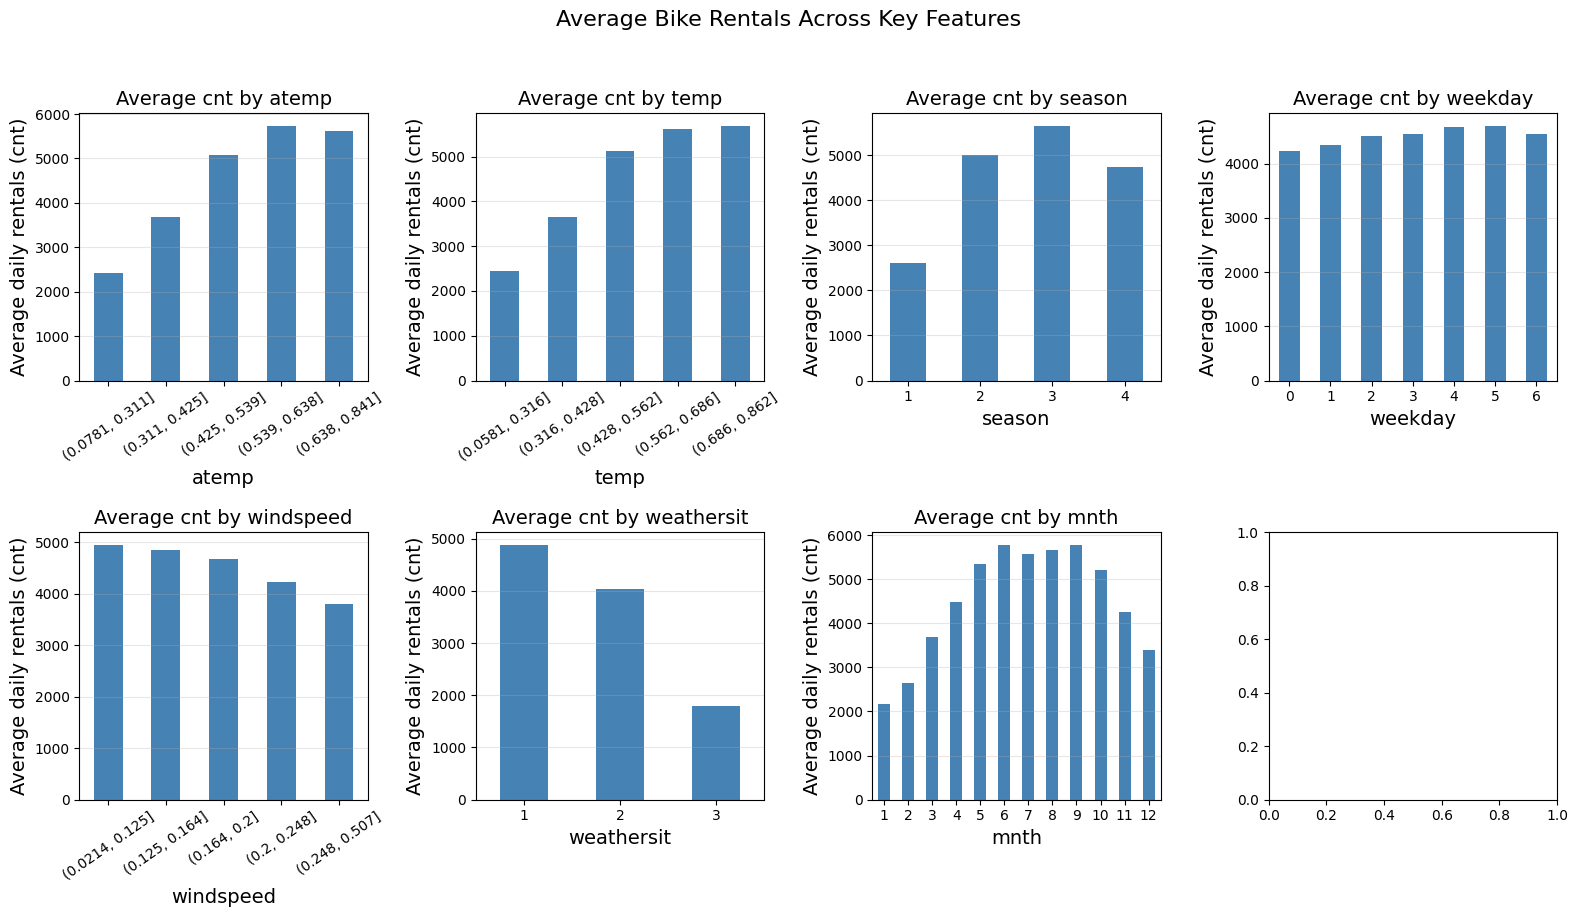

In [260]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare average daily bike rentals across several features.
# `temp` is included alongside `atemp` (the request listed `atemp` twice).
features_to_plot = ["atemp", "temp", "season", "weekday", "windspeed", "weathersit", "mnth"]

fig, axes = plt.subplots(2, 4, figsize=(16, 9))

for ax, feature in zip(axes.flat, features_to_plot):
    if feature not in bike_sharing_full.columns:
        ax.set_visible(False)
        continue

    # Continuous features are divided into five equal-sized ranges so their
    # average rental counts are comparable; categorical features keep values.
    if feature in ["atemp", "temp", "windspeed"]:
        plot_data = bike_sharing_full[[feature, "cnt"]].copy()
        plot_data["group"] = pd.qcut(plot_data[feature], q=5, duplicates="drop")
        averages = plot_data.groupby("group", observed=True)["cnt"].mean()
        averages.plot(kind="bar", ax=ax, color="steelblue")
        ax.set_xlabel(feature)
        ax.tick_params(axis="x", rotation=35)
    else:
        averages = bike_sharing_full.groupby(feature)["cnt"].mean()
        averages.plot(kind="bar", ax=ax, color="steelblue")
        ax.set_xlabel(feature)
        ax.tick_params(axis="x", rotation=0)

    ax.set_title(f"Average cnt by {feature}")
    ax.set_ylabel("Average daily rentals (cnt)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Average Bike Rentals Across Key Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Create a Test Set

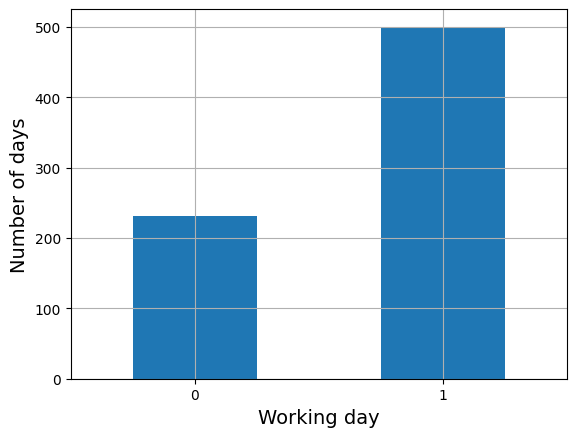

In [261]:
cat_counts = bike_sharing_full["workingday"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Working day")
plt.ylabel("Number of days")

plt.show()

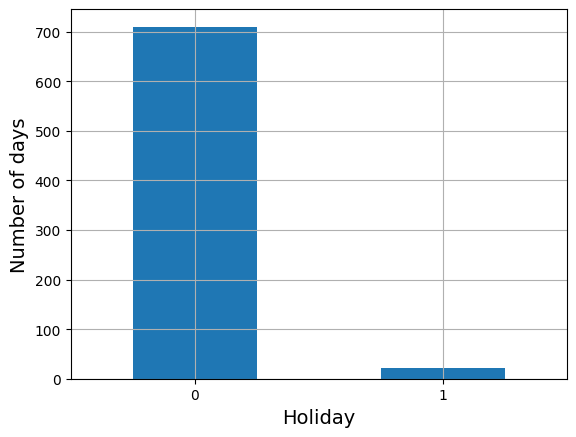

In [262]:
cat_counts = bike_sharing_full["holiday"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Holiday")
plt.ylabel("Number of days")

plt.show()

In [263]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    bike_sharing_full, test_size=0.2, stratify=bike_sharing_full["season"],
    random_state=42)

In [264]:
bike_sharing_full["season"].value_counts() / len(bike_sharing_full)

season
3    0.257182
2    0.251710
1    0.247606
4    0.243502
Name: count, dtype: float64

In [265]:
strat_test_set["season"].value_counts() / len(strat_test_set)

season
3    0.258503
2    0.251701
1    0.244898
4    0.244898
Name: count, dtype: float64

In [295]:
season_comparison = pd.DataFrame({
    "full_data": bike_sharing_full["season"].value_counts(normalize=True).sort_index(),
    "train": strat_train_set["season"].value_counts(normalize=True).sort_index(),
    "test": strat_test_set["season"].value_counts(normalize=True).sort_index(),
})

season_comparison

,full_data,train,test
season,,,
1,0.247606,0.248288,0.244898
2,0.251710,0.251712,0.251701
3,0.257182,0.256849,0.258503
4,0.243502,0.243151,0.244898


# Discover and Visualize the Data to Gain Insights

In [266]:
bike_sharing = strat_train_set.copy()

## Looking for Correlations

In [267]:
corr_matrix = bike_sharing.corr(numeric_only=True)

In [268]:
corr_matrix["cnt"].sort_values(ascending=False)

cnt            1.000000
registered     0.948001
casual         0.669396
atemp          0.641780
temp           0.637256
yr             0.578027
season         0.406214
mnth           0.292580
casualRatio    0.232139
workingday     0.078573
weekday        0.064091
hum           -0.072021
holiday       -0.095913
windspeed     -0.238051
weathersit    -0.293843
Name: cnt, dtype: float64

In [269]:
corr_matrix["casualRatio"].sort_values(ascending=False)

casualRatio    1.000000
casual         0.823144
atemp          0.328320
temp           0.324311
cnt            0.232139
holiday        0.140802
season         0.080235
mnth           0.059596
weekday        0.001006
hum           -0.020822
windspeed     -0.061838
registered    -0.066002
yr            -0.070615
weathersit    -0.161849
workingday    -0.712641
Name: casualRatio, dtype: float64

### Visualizing Features Related to `casualRatio`

The correlation results identify the strongest **linear** relationships with `casualRatio`. The plots below use:

- **Scatter plots** for numeric features (`atemp`, `temp`, and `cnt`).
- **Box plots** for categorical or binary features (`holiday`, `weathersit`, and `workingday`).

`workingday` has the strongest relationship ($r \approx -0.73$): casual riders make up a substantially smaller share of rentals on working days. Correlation alone does not establish causation, and `cnt` should not be used as a predictive feature if it is unavailable at prediction time.

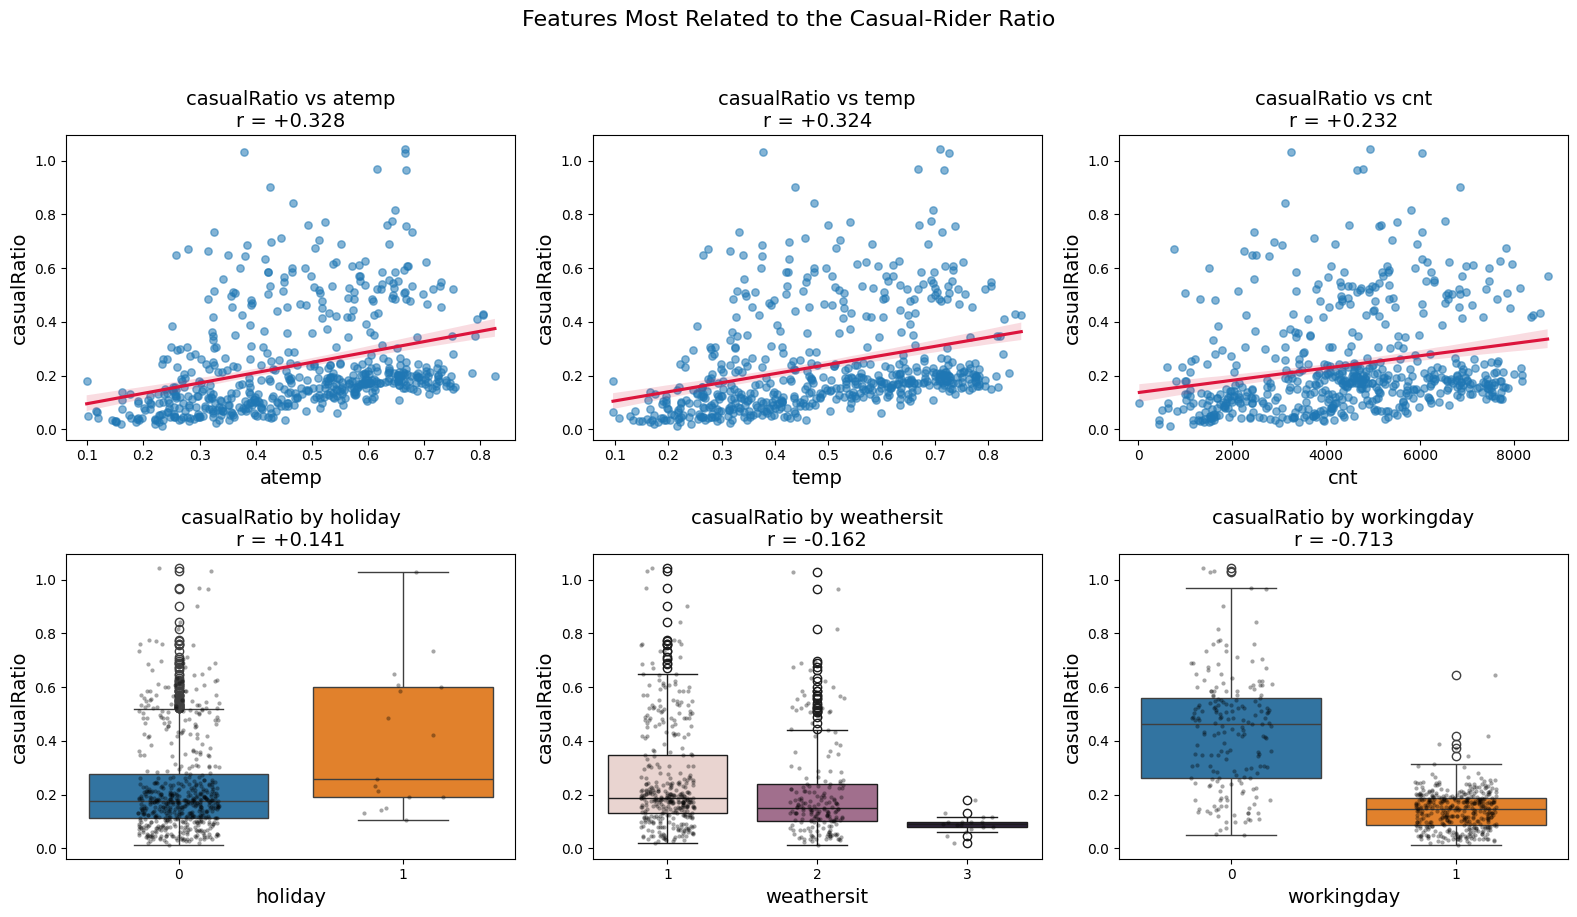

In [270]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use the complete training data so this visualization remains valid even after
# the modeling section removes target-derived columns from `bike_sharing`.
eda_data = strat_train_set.copy()
eda_data["casualRatio"] = eda_data["casual"] / eda_data["registered"]

numeric_features = ["atemp", "temp", "cnt"]
categorical_features = ["holiday", "weathersit", "workingday"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Numeric features: show the observed relationship and a fitted linear trend.
for ax, feature in zip(axes[0], numeric_features):
    correlation = eda_data[[feature, "casualRatio"]].corr().iloc[0, 1]
    sns.regplot(
        data=eda_data,
        x=feature,
        y="casualRatio",
        ax=ax,
        scatter_kws={"alpha": 0.55, "s": 28},
        line_kws={"color": "crimson"},
    )
    ax.set_title(f"casualRatio vs {feature}\nr = {correlation:+.3f}")

# Categorical/binary features: compare the distribution in each category.
for ax, feature in zip(axes[1], categorical_features):
    correlation = eda_data[[feature, "casualRatio"]].corr().iloc[0, 1]
    sns.boxplot(data=eda_data, x=feature, y="casualRatio", ax=ax, hue=feature, legend=False)
    sns.stripplot(
        data=eda_data,
        x=feature,
        y="casualRatio",
        ax=ax,
        color="black",
        alpha=0.35,
        size=3,
        jitter=0.18,
    )
    ax.set_title(f"casualRatio by {feature}\nr = {correlation:+.3f}")

fig.suptitle("Features Most Related to the Casual-Rider Ratio", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Understanding Scatter Plots for Correlation

The scatter_matrix below creates a grid of plots showing relationships between all pairs of variables:

**What it shows:**
- **Diagonal** (top-left to bottom-right): Histograms of each feature's distribution
- **Off-diagonal cells**: Scatter plots showing the relationship between two variables

**How to spot HIGH CORRELATION in scatter plots:**

| Pattern | Correlation Strength | What it means |
|:--|:--:|:--|
| **Tight upward diagonal** ↗️ | \|r\| ≥ 0.7 | Strong positive — as X increases, Y increases predictably |
| **Tight downward diagonal** ↘️ | \|r\| ≤ -0.7 | Strong negative — as X increases, Y decreases predictably |
| **Loose/scattered points** | 0.3 to 0.5 | Weak correlation — some trend but lots of scatter |
| **Random cloud (no pattern)** | < 0.3 | No correlation — points scattered everywhere |
| **Vertical or horizontal line** | ≈ 0 | No relationship — one variable doesn't vary with the other |

**Key examples from our data:**
- **`cnt` vs `registered`** (+0.944): Very tight upward line ↗️ — almost perfect correlation
- **`cnt` vs `atemp`** (+0.643): Upward trend but more scatter — moderate positive
- **`casualRatio` vs `workingday`** (-0.727): Downward pattern ↘️ — strong negative
- **`cnt` vs `weekday`** (+0.053): Random cloud — no meaningful pattern

**Visual tip:** In a scatter_matrix, **tight trends = high relevance**, **blob/random scatter = low relevance**

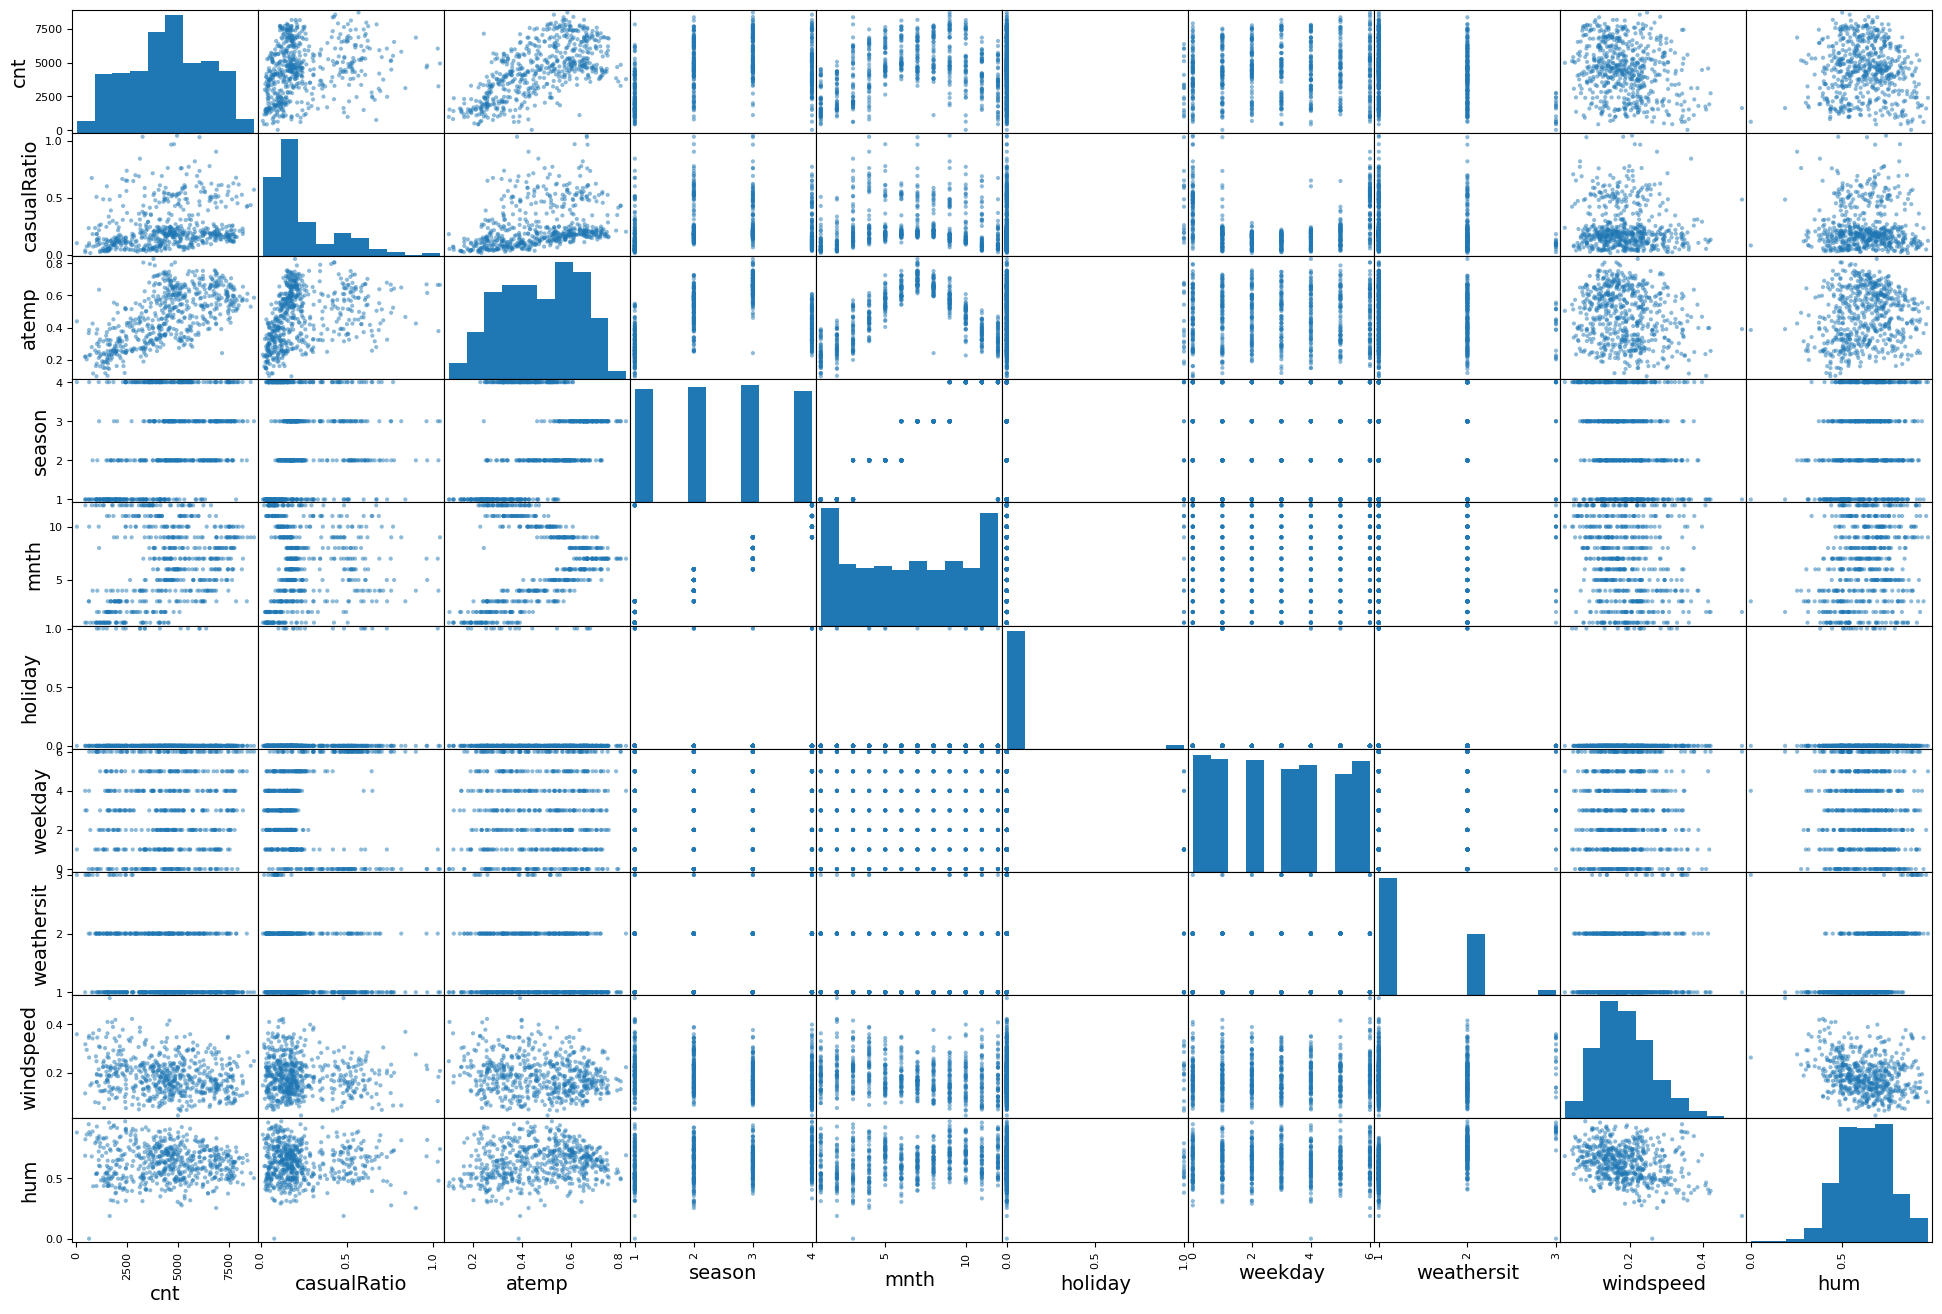

In [271]:
from pandas.plotting import scatter_matrix

attributes = ["cnt","casualRatio", "atemp", "season", "mnth",
              "holiday", "weekday", "weathersit", "windspeed", "hum"]
scatter_matrix(bike_sharing[attributes], figsize=(24, 16))

plt.show()

## Experimenting with Attribute Combinations

| Combination | Feature idea | Why it may help |
|---|---|---|
| Temperature × humidity | `temp * hum` | Warm, humid days may reduce riding more than either factor alone. |
| Temperature × wind | `temp * windspeed` | Wind is more unpleasant when it is cold. |
| Weather × working day | `weathersit * workingday` | Bad weather may affect commuting days differently from weekends. |
| Season × weather | `season * weathersit` | The effect of rain/clouds can differ by season. |
| Month × year | `mnth * yr` | Captures whether usage changed differently over months from 2011 to 2012. |
| Feels-like gap | `atemp - temp` | Measures how perceived temperature differs from actual temperature. |
| Cyclic month / weekday | sine and cosine versions | January and December should be “near” each other, not far apart. |

In [272]:
# Create interaction and cyclic features, then test whether they improve model performance.
bike_sharing.info()

bike_sharing["temp_humidity"] = bike_sharing["temp"] * bike_sharing["hum"]
bike_sharing["temp_wind"] = bike_sharing["temp"] * bike_sharing["windspeed"]
bike_sharing["weather_workingday"] = bike_sharing["weathersit"] * bike_sharing["workingday"]
bike_sharing["season_weather"] = bike_sharing["season"] * bike_sharing["weathersit"]
bike_sharing["feels_like_gap"] = bike_sharing["atemp"] - bike_sharing["temp"]

import numpy as np
bike_sharing["month_sin"] = bike_sharing["mnth"].apply(lambda x: np.sin(2 * np.pi * x / 12))
bike_sharing["month_cos"] = bike_sharing["mnth"].apply(lambda x: np.cos(2 * np.pi * x / 12))
bike_sharing["weekday_sin"] = bike_sharing["weekday"].apply(lambda x: np.sin(2 * np.pi * x / 7))
bike_sharing["weekday_cos"] = bike_sharing["weekday"].apply(lambda x: np.cos(2 * np.pi * x / 7))

bike_sharing.head()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 373 to 1
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       584 non-null    int64  
 1   yr           584 non-null    int64  
 2   mnth         584 non-null    int64  
 3   holiday      584 non-null    int64  
 4   weekday      584 non-null    int64  
 5   workingday   584 non-null    int64  
 6   weathersit   584 non-null    int64  
 7   temp         584 non-null    float64
 8   atemp        584 non-null    float64
 9   hum          584 non-null    float64
 10  windspeed    584 non-null    float64
 11  casual       584 non-null    int64  
 12  registered   584 non-null    int64  
 13  cnt          584 non-null    int64  
 14  casualRatio  584 non-null    float64
dtypes: float64(5), int64(10)
memory usage: 73.0 KB


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,...,casualRatio,temp_humidity,temp_wind,weather_workingday,season_weather,feels_like_gap,month_sin,month_cos,weekday_sin,weekday_cos
instant,,,,,,,,,,,,,,,,,,,,,
373,1,1,1,0,0,0,1,0.337500,0.340258,0.465000,...,0.211960,0.156938,0.064645,0,1,0.002758,5.000000e-01,8.660254e-01,0.000000,1.000000
119,2,0,4,0,5,1,1,0.510000,0.497463,0.457083,...,0.236212,0.233112,0.122432,1,2,-0.012537,8.660254e-01,-5.000000e-01,-0.974928,-0.222521
139,2,0,5,0,4,1,2,0.530833,0.510742,0.829583,...,0.191406,0.440370,0.057443,2,4,-0.020091,5.000000e-01,-8.660254e-01,-0.433884,-0.900969
165,2,0,6,0,2,1,1,0.604167,0.591546,0.507083,...,0.174592,0.306363,0.162692,1,2,-0.012621,1.224647e-16,-1.000000e+00,0.974928,-0.222521
268,4,0,9,0,0,0,2,0.634167,0.572637,0.845000,...,0.445470,0.535871,0.031949,0,8,-0.061530,-1.000000e+00,-1.836970e-16,0.000000,1.000000


In [273]:
import numpy as np

extended = [
    "temp_humidity",
    "temp_wind",
    "weather_workingday",
    "season_weather",
    "feels_like_gap",
    "month_sin",
    "month_cos",
    "weekday_sin",
    "weekday_cos",
]

present = [c for c in extended if c in bike_sharing.columns]
if not present:
    raise ValueError("None of the extended features are present in `bike_sharing`")

corr = bike_sharing[present + ["cnt"]].corr()
corr_to_cnt = corr["cnt"].loc[present].sort_values(ascending=False)
print(corr_to_cnt)

temp_humidity         0.472805
temp_wind             0.294379
season_weather        0.092521
weekday_sin          -0.023324
weekday_cos          -0.053418
weather_workingday   -0.100855
feels_like_gap       -0.389112
month_sin            -0.394816
month_cos            -0.448691
Name: cnt, dtype: float64


### Correlation Analysis of Extended Features

- **Strongest positive:** `temp_humidity` (0.45) — warm + humid days associate with higher counts.
- **Moderate positive:** `temp_wind` (0.31) — higher temperature interacting with wind relates to increased rides.
- **Small / negligible:** `season_weather` (0.08), `weather_workingday` (-0.13), `weekday_sin` / `weekday_cos` (~-0.04 to -0.05).
- **Strongest negatives:** `month_cos` (-0.46), `month_sin` (-0.37), `feels_like_gap` (-0.39).

Notes:

- The `month_sin` / `month_cos` pair captures seasonality (a dominant effect); their signs reflect phase rather than independent negative influence.
- `feels_like_gap = atemp - temp` has a negative correlation with `cnt`, suggesting larger perceived-vs-measured temperature gaps associate with fewer rides (discomfort or sensor/encoding effect).
- Beware multicollinearity: `month_sin` and `month_cos` are related, and interaction features derived from `temp`, `hum`, and `windspeed` will correlate with their base variables.

Recommended next steps:

1. Run VIF to identify highly collinear features and consider dropping or regularizing them.
2. Fit a standardized linear regression to compare effect sizes on the same scale.
3. Visualize monthly averages and scatterplots for the top features to inspect non-linear patterns and outliers.


Present features: ['temp_humidity', 'temp_wind', 'weather_workingday', 'season_weather', 'feels_like_gap', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
VIF for extended features:
 temp_humidity         3.176770
month_cos             2.960670
weather_workingday    2.509230
season_weather        2.248180
month_sin             2.229300
feels_like_gap        1.953362
weekday_cos           1.902774
temp_wind             1.598419
weekday_sin           1.174721
dtype: float64
Standardized coefficients (sorted by magnitude):
 month_cos            -794.127418
month_sin            -749.236501
weather_workingday   -401.804578
weekday_cos          -358.552374
temp_humidity         166.073156
season_weather        -67.603215
weekday_sin            59.390266
temp_wind             -50.327584
feels_like_gap         37.800119
dtype: float64


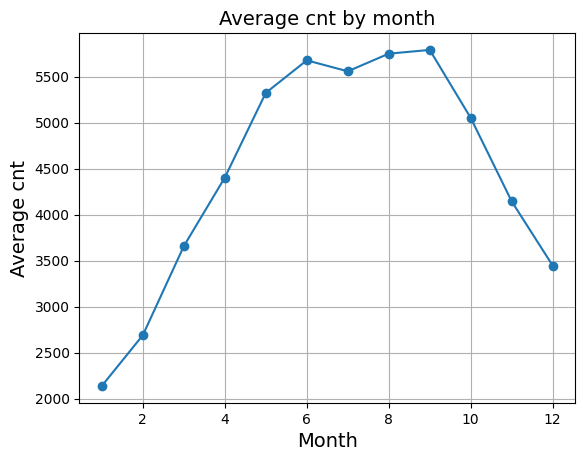

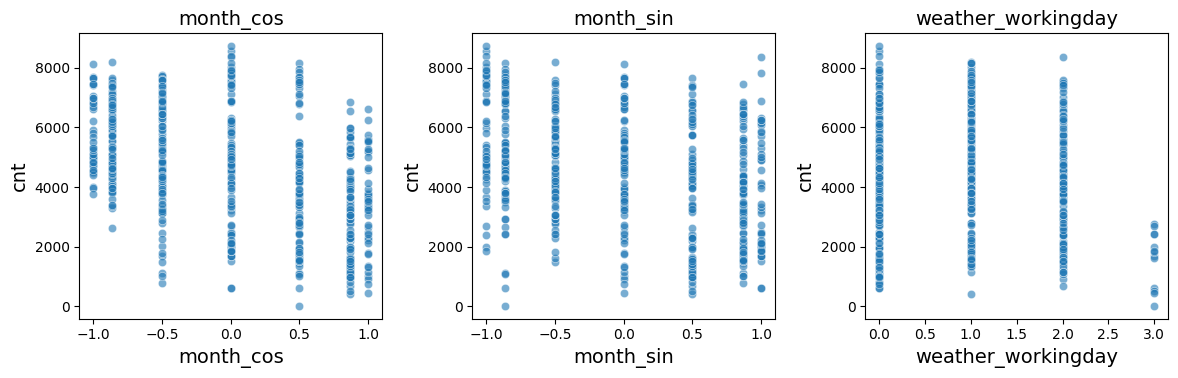

In [274]:
import pandas as pd
import numpy as np
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# list of extended features you added
extended = [
    "temp_humidity","temp_wind","weather_workingday","season_weather",
    "feels_like_gap","month_sin","month_cos","weekday_sin","weekday_cos",
]
present = [c for c in extended if c in bike_sharing.columns]
print("Present features:", present)

# 1) VIF for the extended features you added
X = bike_sharing[present].dropna()
Xc = add_constant(X)
vif_values = []
for i in range(1, Xc.shape[1]):
    with np.errstate(divide="ignore", invalid="ignore"):
        vif_i = variance_inflation_factor(Xc.values, i)
    vif_values.append(np.inf if not np.isfinite(vif_i) else vif_i)
vif = pd.Series(vif_values, index=present)
print("VIF for extended features:\n", vif.sort_values(ascending=False))

# 1b) VIF for all numeric features (not just the extended ones)
all_numeric_features = [
    c for c in bike_sharing.columns
    if c not in ["cnt", "casual", "registered"] and pd.api.types.is_numeric_dtype(bike_sharing[c])
]
X_all = bike_sharing[all_numeric_features].dropna()
Xc_all = add_constant(X_all)
vif_values_all = []
for i in range(1, Xc_all.shape[1]):
    with np.errstate(divide="ignore", invalid="ignore"):
        vif_i = variance_inflation_factor(Xc_all.values, i)
    vif_values_all.append(np.inf if not np.isfinite(vif_i) else vif_i)
vif_all = pd.Series(vif_values_all, index=all_numeric_features)
# print("\nVIF for all numeric features:\n", vif_all.sort_values(ascending=False))

# 2) Standardized linear regression coefficients
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
y = bike_sharing.loc[X.index, "cnt"].values
lr = LinearRegression().fit(Xs, y)
coef = pd.Series(lr.coef_, index=present).sort_values(key=lambda s: s.abs(), ascending=False)
print("Standardized coefficients (sorted by magnitude):\n", coef)

# 3) Monthly average plot (seasonality)
if "mnth" in bike_sharing.columns:
    monthly = bike_sharing.groupby("mnth")["cnt"].mean()
    plt.figure()
    monthly.plot(marker='o')
    plt.title("Average cnt by month")
    plt.xlabel("Month")
    plt.ylabel("Average cnt")
    plt.grid(True)

# 4) Scatter plots for top 3 absolute coeff features
top3 = coef.abs().nlargest(3).index.tolist()
plt.figure(figsize=(12,4))
for i, f in enumerate(top3,1):
    plt.subplot(1,3,i)
    sns.scatterplot(x=bike_sharing[f], y=bike_sharing["cnt"], alpha=0.6)
    plt.title(f)
plt.tight_layout()

Compacted conversationI will explain the VIF values in plain language and connect them to the feature set in your notebook.

VIF tells you how much a feature is “redundant” with the other features in the model.

A simple rule of thumb is:

- VIF = 1: no multicollinearity problem
- VIF between 1 and 5: mild to moderate collinearity, usually acceptable
- VIF between 5 and 10: concerning
- VIF > 10: severe multicollinearity

For your results:

- `temp_humidity` = 3.09
- `month_cos` = 2.73
- `weather_workingday` = 2.57
- `season_weather` = 2.30
- `month_sin` = 2.22
- `feels_like_gap` = 1.94
- `weekday_cos` = 1.86
- `temp_wind` = 1.55
- `weekday_sin` = 1.17

Interpretation:
- All of these are below 5, so the multicollinearity is not severe.
- The largest values suggest some moderate overlap, especially for `temp_humidity`, `month_cos`, `weather_workingday`, and `season_weather`.
- The lowest values, such as `weekday_sin` and `temp_wind`, are relatively independent.

In short: your features are not showing a serious multicollinearity problem, but a few of them are somewhat correlated with the rest of the feature set.

I’m clarifying the meaning of that VIF number so you can connect it to the feature it measures.

The value 3.09 for `temp_humidity` does not mean “`temp_humidity` is correlated with one specific feature” in the ordinary correlation-matrix sense.

It means:

- `temp_humidity` is moderately linearly related to the other features in the set.
- In other words, its variance is partly explained by the other predictors.

So the VIF number is about the feature’s relationship with the rest of the feature set, not with one single named feature.

How to interpret it:
- A VIF of 3.09 means `temp_humidity` has about 2.09 times more variance than it would if it were independent of the other features.
- That is usually a sign of mild-to-moderate multicollinearity, not severe collinearity.

If you want to know which feature is most responsible, you would inspect:
- the correlation of `temp_humidity` with each other feature, or
- the regression of `temp_humidity` on the others.

For example:
```python
corr = bike_sharing[["temp_humidity", "temp", "hum", "windspeed", "atemp", "season", "weathersit", "workingday"]].corr()
print(corr["temp_humidity"].sort_values(ascending=False))
```

In your case, `temp_humidity` is likely related to base variables such as:
- `temp`
- `hum`
- `atemp`

because it is built from them. That is why its VIF is not tiny.

These coefficients are from a standardized linear regression, so they are comparable across features.

What they mean:
- The sign tells direction:
  - negative means higher values of that feature are associated with lower predicted `cnt`
  - positive means higher values are associated with higher predicted `cnt`
- The magnitude tells strength:
  - larger absolute value = stronger effect on the model’s prediction

For your output:

- `month_cos` = -846.27
- `month_sin` = -736.20

These are the largest effects, which suggests seasonality is very important in the model. Because the two month features are cyclic, they are acting together to capture the yearly pattern.

- `weather_workingday` = -390.48

This indicates that the interaction between weather and workingday has a strong negative effect on rentals.

- `weekday_cos` = -316.30

This is another strong seasonal/weekly pattern effect.

- `temp_humidity` = 112.95

This is positive and much smaller than the month effects, but still meaningful. It says that after standardization, increases in this feature raise predicted `cnt`.

- `season_weather`, `feels_like_gap`, `weekday_sin`, `temp_wind`

These are smaller effects, so they contribute less to the prediction.

Important note:
- These are not “correlation coefficients” like Pearson $r$.
- They are model coefficients from a linear regression, so they reflect the effect of each feature after accounting for the others.

Also, because the features are standardized:
- a coefficient of $100$ means a 1 standard deviation increase in that feature changes the predicted `cnt` by about $100$ units, all else equal.

So the main takeaway is:
- the month-related features dominate the model,
- `weather_workingday` is also important,
- and the other engineered features have smaller effects.

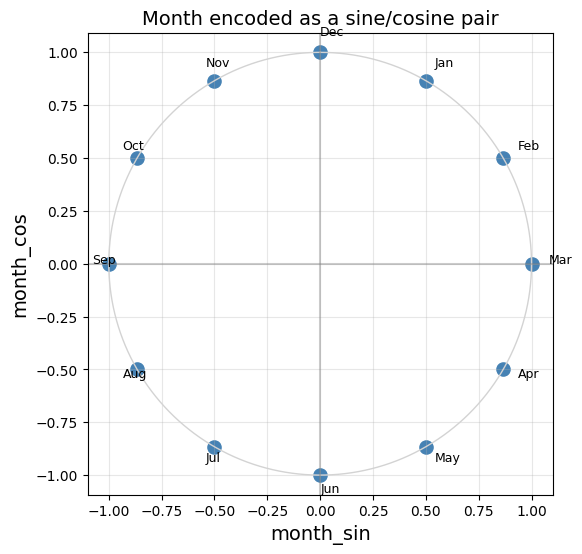

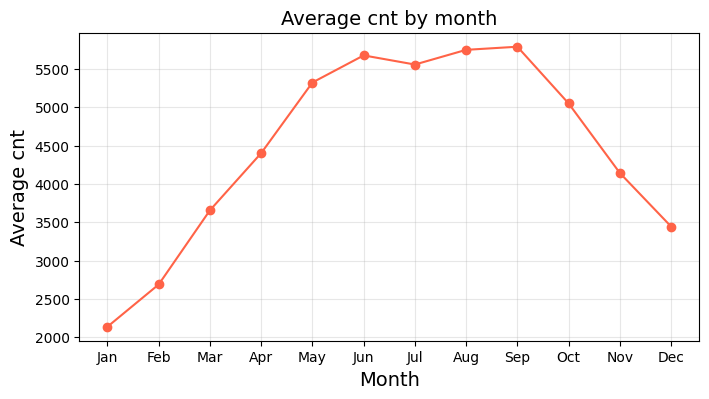

In [275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot the month pair as points on a circle
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_numbers = np.arange(1, 13)

month_df = pd.DataFrame({
    "mnth": month_numbers,
    "month_sin": np.sin(2 * np.pi * month_numbers / 12),
    "month_cos": np.cos(2 * np.pi * month_numbers / 12),
    "month_name": month_names,
})

plt.figure(figsize=(6, 6))
angles = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.sin(angles), np.cos(angles), color="lightgray", lw=1)
plt.scatter(month_df["month_sin"], month_df["month_cos"], s=90, color="steelblue")

for _, row in month_df.iterrows():
    plt.text(row["month_sin"] * 1.08, row["month_cos"] * 1.08, row["month_name"], fontsize=9)

plt.axhline(0, color="gray", alpha=0.4)
plt.axvline(0, color="gray", alpha=0.4)
plt.title("Month encoded as a sine/cosine pair")
plt.xlabel("month_sin")
plt.ylabel("month_cos")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

# Show the average bike rentals by month using the same seasonal encoding
monthly_avg = bike_sharing.groupby("mnth")["cnt"].mean().reset_index()
monthly_avg = monthly_avg.merge(month_df, on="mnth")

plt.figure(figsize=(8, 4))
plt.plot(monthly_avg["month_name"], monthly_avg["cnt"], marker="o", color="tomato")
plt.title("Average cnt by month")
plt.xlabel("Month")
plt.ylabel("Average cnt")
plt.grid(True, alpha=0.3)
plt.show()

# Prepare the Data for Machine Learning Algorithms

In [319]:
bike_sharing = strat_train_set.drop(["cnt", "casual", "registered"], axis=1)

bike_sharing_labels = strat_train_set["cnt"].copy()

## Data Cleaning

In [277]:
null_rows_idx = bike_sharing.isnull().any(axis=1)
bike_sharing.loc[null_rows_idx].head()


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casualRatio
instant,,,,,,,,,,,,


In [278]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

imputer.fit(bike_sharing)

imputer.statistics_

array([2.5       , 0.        , 7.        , 0.        , 3.        ,
       1.        , 1.        , 0.4945835 , 0.4816835 , 0.63125   ,
       0.179725  , 0.17831984])

In [279]:
imputer_statistics = pd.Series(
    imputer.statistics_,
    index=bike_sharing.columns,
    name="median_used_for_imputation",
)
imputer_statistics

season         2.500000
yr             0.000000
mnth           7.000000
holiday        0.000000
weekday        3.000000
workingday     1.000000
weathersit     1.000000
temp           0.494584
atemp          0.481683
hum            0.631250
windspeed      0.179725
casualRatio    0.178320
Name: median_used_for_imputation, dtype: float64

In [280]:
imputer.feature_names_in_

array(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casualRatio'],
      dtype=object)

drop some outliers

In [281]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(bike_sharing)

In [282]:
outlier_pred

outlier_pred_df = pd.DataFrame(
    {"outlier_prediction": outlier_pred},
    index=bike_sharing.index,
)

outlier_pred_df.head()

,outlier_prediction
instant,
373,-1
119,1
139,1
165,1
268,-1


In [283]:
outlier_df = bike_sharing.loc[outlier_pred_df["outlier_prediction"] == -1]
outlier_df = bike_sharing.iloc[outlier_pred == -1]
outlier_df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casualRatio
instant,,,,,,,,,,,,
373,1,1,1,0,0,0,1,0.337500,0.340258,0.465000,0.191542,0.211960
268,4,0,9,0,0,0,2,0.634167,0.572637,0.845000,0.050379,0.445470
436,1,1,3,0,0,0,1,0.361739,0.359670,0.476957,0.222587,0.509683
150,2,0,5,1,1,0,1,0.733333,0.671092,0.685000,0.131225,0.607689
107,2,0,4,0,0,0,1,0.456667,0.445696,0.479583,0.303496,0.712717


## Handling Text and Categorical Attributes

In [284]:
bike_sharing_cat = bike_sharing[["season", "mnth", "weekday", "weathersit"]]
bike_sharing_cat.head()

,season,mnth,weekday,weathersit
instant,,,,
373,1,1,0,1
119,2,4,5,1
139,2,5,4,2
165,2,6,2,1
268,4,9,0,2


### Should these features use one-hot encoding?

Some category values are stored as integers, but their numbers do not always represent a meaningful numeric distance. For example, month `12` is adjacent to month `1`, not far away from it.

| Feature | Suggested treatment | Why |
|---|---|---|
| `season` | One-hot encode | The values label seasons; they are not a numeric scale. |
| `yr`, `holiday`, `workingday` | Keep as binary `0`/`1` | These features already have two states. |
| `mnth`, `weekday` | One-hot encode, or use sine/cosine features | These are categorical and cyclic. |
| `weathersit` | Compare ordinal and one-hot versions | Weather severity has an order, but one-hot encoding can model a separate effect per category. |

One-hot encoding is most useful for **linear, distance-based, and neural-network models**, because it avoids artificial numeric relationships between category codes. It is less essential for **tree-based models** such as decision trees, random forests, and gradient boosting; compare validation performance using both representations.

Encoding all seven features produces about 32 indicator columns, which is a small expansion for this dataset. For linear models with an intercept, consider dropping one indicator per feature to avoid redundant columns; the dropped category becomes the baseline.

In [285]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
bike_sharing_cat_encoded = cat_encoder.fit_transform(bike_sharing_cat)

In [286]:
bike_sharing_cat_encoded[:8]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 32 stored elements and shape (8, 26)>

In [287]:
cat_encoder.categories_

[array([1, 2, 3, 4]),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 array([0, 1, 2, 3, 4, 5, 6]),
 array([1, 2, 3])]

In [288]:
cat_encoder.get_feature_names_out()

array(['season_1', 'season_2', 'season_3', 'season_4', 'mnth_1', 'mnth_2',
       'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8',
       'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_0',
       'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5',
       'weekday_6', 'weathersit_1', 'weathersit_2', 'weathersit_3'],
      dtype=object)

In [289]:
df_output = pd.DataFrame(bike_sharing_cat_encoded.toarray(),
                         columns=cat_encoder.get_feature_names_out(),
                         index=bike_sharing_cat.index)

df_output.head()

,season_1,season_2,season_3,season_4,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,...,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3
instant,,,,,,,,,,,,,,,,,,,,,
373,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
119,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
139,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
165,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
268,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [332]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Recreate the modeling data here to ensure target-derived columns are excluded.
leakage_columns = ["cnt", "casual", "registered", "casualRatio"]
bike_sharing = strat_train_set.drop(columns=leakage_columns)
y_train = strat_train_set["cnt"].copy()

# Encode only nominal categorical features.
cat_columns = ["season", "mnth", "weekday", "weathersit"]

# All remaining columns pass through without one-hot encoding.
preprocessing = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_columns),
    ],
    remainder="passthrough",
)

X_train_encoded = preprocessing.fit_transform(bike_sharing)

print("Leakage-free training feature count:", bike_sharing.shape[1])
print("Encoded training shape:", X_train_encoded.shape)

Leakage-free training feature count: 11
Encoded training shape: (584, 33)


In [ ]:
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=preprocessing.get_feature_names_out(),
    index=bike_sharing.index,
)

X_train_encoded_df.head()

,cat__season_1,cat__season_2,cat__season_3,cat__season_4,cat__mnth_1,cat__mnth_2,cat__mnth_3,cat__mnth_4,cat__mnth_5,cat__mnth_6,...,cat__weathersit_2,cat__weathersit_3,remainder__yr,remainder__holiday,remainder__workingday,remainder__temp,remainder__atemp,remainder__hum,remainder__windspeed,remainder__casualRatio
instant,,,,,,,,,,,,,,,,,,,,,
373,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.337500,0.340258,0.465000,0.191542,0.211960
119,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.510000,0.497463,0.457083,0.240063,0.236212
139,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.530833,0.510742,0.829583,0.108213,0.191406
165,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.604167,0.591546,0.507083,0.269283,0.174592
268,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.634167,0.572637,0.845000,0.050379,0.445470


# Select and Train a Model
## Training and Evaluating on the Training Set

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# X_train_encoded was created with:
# preprocessing.fit_transform(bike_sharing)
# y_train is bike_sharing_labels

lr_model = LinearRegression()
lr_model.fit(X_train_encoded, y_train)

# Predictions on the training set
y_train_pred = lr_model.predict(X_train_encoded)

print(f"Training RMSE: {root_mean_squared_error(y_train, y_train_pred):.2f}")
print(f"Training R²:   {r2_score(y_train, y_train_pred):.3f}")

Training RMSE: 754.51
Training R²:   0.851


In [335]:
X_test = strat_test_set.drop(columns=["cnt", "casual", "registered", "casualRatio"])
y_test = strat_test_set["cnt"]

# Important: transform only — do not fit the encoder again on test data.
X_test_encoded = preprocessing.transform(X_test)

y_test_pred = lr_model.predict(X_test_encoded)

print(f"Test RMSE: {root_mean_squared_error(y_test, y_test_pred):.2f}")
print(f"Test R²:   {r2_score(y_test, y_test_pred):.3f}")

Test RMSE: 763.00
Test R²:   0.832


In [336]:
bike_sharing_predictions = lr_model.predict(X_test_encoded)
bike_sharing_predictions[:5],round(2)

(array([4867.99914356, 5770.85852188, 2813.02699767, 5141.59053617,
         899.56882232]),
 2)

In [337]:
y_test[:5].values

array([5180, 4073, 2236, 5202,  705])

In [338]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_encoded, y_train)

# Predictions on the training set
y_train_pred = dt_model.predict(X_train_encoded)

print(f"Training RMSE: {root_mean_squared_error(y_train, y_train_pred):.2f}")
print(f"Training R²:   {r2_score(y_train, y_train_pred):.3f}")

Training RMSE: 0.00
Training R²:   1.000


In [339]:
X_test = strat_test_set.drop(columns=leakage_columns)
y_test = strat_test_set["cnt"]

# Important: transform only — do not fit the encoder again on test data.
X_test_encoded = preprocessing.transform(X_test)

y_test_pred = dt_model.predict(X_test_encoded)

print(f"Test RMSE: {root_mean_squared_error(y_test, y_test_pred):.2f}")
print(f"Test R²:   {r2_score(y_test, y_test_pred):.3f}")

Test RMSE: 998.15
Test R²:   0.713


In [340]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf_model = RandomForestRegressor(random_state=42, max_features=8)
rf_model.fit(X_train_encoded, y_train)


# Predictions on the training set
y_train_pred = rf_model.predict(X_train_encoded)

print(f"Training RMSE: {root_mean_squared_error(y_train, y_train_pred):.2f}")
print(f"Training R²:   {r2_score(y_train, y_train_pred):.3f}")

Training RMSE: 250.92
Training R²:   0.983


In [330]:
X_test = strat_test_set.drop(columns=leakage_columns)
y_test = strat_test_set["cnt"]

# Important: transform only — do not fit the encoder again on test data.
X_test_encoded = preprocessing.transform(X_test)

y_test_pred = rf_model.predict(X_test_encoded)

print(f"Test RMSE: {root_mean_squared_error(y_test, y_test_pred):.2f}")
print(f"Test R²:   {r2_score(y_test, y_test_pred):.3f}")

Test RMSE: 675.01
Test R²:   0.869


In [308]:
forest_rmses = -cross_val_score(rf_model, X_train_encoded, y_train,
                                scoring="neg_root_mean_squared_error", cv=10)

pd.Series(forest_rmses).describe()

count     10.000000
mean     667.606994
std      123.660692
min      475.496463
25%      577.382716
50%      660.793241
75%      770.554110
max      858.644804
dtype: float64

# Fine-Tune Your Model

## Grid Search

In [331]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("random_forest", RandomForestRegressor(random_state=42))
])
param_grid = [
    {"random_forest__max_features": [4, 6, 8]}
]
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
)
grid_search.fit(X_train_encoded, y_train)

# Summarize every parameter combination in RMSE units (lower is better).
results = pd.DataFrame(grid_search.cv_results_)[
    [
        "param_random_forest__max_features",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]
].copy()
results["mean_rmse"] = -results["mean_test_score"]
results["std_rmse"] = results["std_test_score"]
results = results.sort_values("rank_test_score")

print("Cross-validation results (lower RMSE is better):")
display(results[["param_random_forest__max_features", "mean_rmse", "std_rmse", "rank_test_score"]])
print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation RMSE: {-grid_search.best_score_:.2f}")

Cross-validation results (lower RMSE is better):


,param_random_forest__max_features,mean_rmse,std_rmse,rank_test_score
2,8,713.480413,26.154438,1
1,6,718.556385,11.551804,2
0,4,750.800841,20.410745,3


Best parameters: {'random_forest__max_features': 8}
Best cross-validation RMSE: 713.48


In [333]:
best_model = grid_search.best_estimator_

best_test_predictions = best_model.predict(X_test_encoded)

print(f"Best test RMSE: {root_mean_squared_error(y_test, best_test_predictions):.2f}")
print(f"Best test R²:   {r2_score(y_test, best_test_predictions):.3f}")

Best test RMSE: 675.01
Best test R²:   0.869


In [342]:
# Focused Grid Search: 16 promising configurations across 3 folds (48 fits).
# The earlier 108-configuration search was unnecessarily expensive for this dataset.
focused_param_grid = {
    "random_forest__n_estimators": [200],
    "random_forest__max_features": [6, 8],
    "random_forest__max_depth": [None, 15],
    "random_forest__min_samples_split": [2, 5],
    "random_forest__min_samples_leaf": [1, 2],
}

focused_grid_search = GridSearchCV(
    estimator=Pipeline([
        ("random_forest", RandomForestRegressor(random_state=42, n_jobs=1)),
    ]),
    param_grid=focused_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
focused_grid_search.fit(X_train_encoded, y_train)

# Display every configuration in ordinary RMSE units (lower is better).
focused_results = pd.DataFrame(focused_grid_search.cv_results_).copy()
focused_results["mean_rmse"] = -focused_results["mean_test_score"]
focused_results["std_rmse"] = focused_results["std_test_score"]
columns_to_show = [
    "param_random_forest__n_estimators",
    "param_random_forest__max_features",
    "param_random_forest__max_depth",
    "param_random_forest__min_samples_split",
    "param_random_forest__min_samples_leaf",
    "mean_rmse",
    "std_rmse",
    "rank_test_score",
]
display(focused_results.sort_values("rank_test_score")[columns_to_show])

print("Best parameters:", focused_grid_search.best_params_)
print(f"Best cross-validation RMSE: {-focused_grid_search.best_score_:.2f}")

# Evaluate the selected model once on the untouched test set.
best_focused_model = focused_grid_search.best_estimator_
focused_test_predictions = best_focused_model.predict(X_test_encoded)
print(f"Best test RMSE: {root_mean_squared_error(y_test, focused_test_predictions):.2f}")
print(f"Best test R²:   {r2_score(y_test, focused_test_predictions):.3f}")

,param_random_forest__n_estimators,param_random_forest__max_features,param_random_forest__max_depth,param_random_forest__min_samples_split,param_random_forest__min_samples_leaf,mean_rmse,std_rmse,rank_test_score
12,200,8,15,2,1,707.519085,23.931720,1
4,200,8,None,2,1,709.467496,18.736478,2
13,200,8,15,5,1,712.018143,19.538239,3
0,200,6,None,2,1,712.713630,18.261706,4
5,200,8,None,5,1,713.467703,21.018070,5
9,200,6,15,5,1,717.960221,19.826314,6
8,200,6,15,2,1,719.020015,21.415818,7
1,200,6,None,5,1,721.365376,20.111775,8
6,200,8,None,2,2,721.552511,31.956619,9
14,200,8,15,2,2,722.685207,30.086901,10


Best parameters: {'random_forest__max_depth': 15, 'random_forest__max_features': 8, 'random_forest__min_samples_leaf': 1, 'random_forest__min_samples_split': 2, 'random_forest__n_estimators': 200}
Best cross-validation RMSE: 707.52
Best test RMSE: 671.31
Best test R²:   0.870


We can compute a 95% confidence interval for the test RMSE using SciPy's `bootstrap()` function:

In [347]:
from scipy.stats import bootstrap

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (focused_test_predictions - y_test) ** 2
boot_result = bootstrap([squared_errors], rmse, confidence_level=confidence,
                        random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [348]:
print(f"95% CI for RMSE: ({rmse_lower:.4f}, {rmse_upper:.4f})")

95% CI for RMSE: (578.7446, 785.4615)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = [
        {'svr__kernel': ['linear'], 'svr__C': [10., 30., 100., 300., 1000.,
                                               3000., 10000., 30000.0]},
        {'svr__kernel': ['rbf'], 'svr__C': [1.0, 3.0, 10., 30., 100., 300.,
                                            1000.0],
         'svr__gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},
    ]

svr_pipeline = Pipeline([("svr", SVR())])
grid_search = GridSearchCV(svr_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(X_train_encoded, y_train)

,estimator,"Pipeline(step...svr', SVR())])"
,param_grid,"[{'svr__C': [10.0, 30.0, ...], 'svr__kernel': ['linear']}, {'svr__C': [1.0, 3.0, ...], 'svr__gamma': [0.01, 0.03, ...], 'svr__kernel': ['rbf']}]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [350]:
best_svr_model = grid_search.best_estimator_
focused_test_predictions = best_svr_model.predict(X_test_encoded)
print(f"Best test RMSE: {root_mean_squared_error(y_test, focused_test_predictions):.2f}")
print(f"Best test R²:   {r2_score(y_test, focused_test_predictions):.3f}")

Best test RMSE: 765.12
Best test R²:   0.831


In [351]:
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score

# Fit feature selection inside the pipeline so each cross-validation fold learns
# importances using only that fold's training data.
selector_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    (
        "selector",
        SelectFromModel(
            RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
            threshold="median",
        ),
    ),
    (
        "random_forest",
        RandomForestRegressor(
            n_estimators=200,
            max_features=8,
            max_depth=15,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

selector_rmses = -cross_val_score(
    selector_pipeline,
    bike_sharing,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
)
print("Feature-selection CV RMSE:")
print(pd.Series(selector_rmses).describe())

# Fit once on all training data to inspect the chosen encoded features.
selector_pipeline.fit(bike_sharing, y_train)
encoded_feature_names = selector_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()
selected_mask = selector_pipeline.named_steps["selector"].get_support()
selected_feature_names = encoded_feature_names[selected_mask]

print(f"Selected {selected_mask.sum()} of {len(encoded_feature_names)} encoded features:")
print(selected_feature_names.tolist())

selector_test_predictions = selector_pipeline.predict(X_test)
print(f"Feature-selection test RMSE: {root_mean_squared_error(y_test, selector_test_predictions):.2f}")
print(f"Feature-selection test R²:   {r2_score(y_test, selector_test_predictions):.3f}")

Feature-selection CV RMSE:
count      3.000000
mean     690.418818
std       44.553217
min      643.679755
25%      669.425667
50%      695.171579
75%      713.788349
max      732.405119
dtype: float64
Selected 17 of 33 encoded features:
['cat__season_1', 'cat__season_4', 'cat__mnth_4', 'cat__mnth_9', 'cat__mnth_10', 'cat__mnth_12', 'cat__weekday_0', 'cat__weekday_6', 'cat__weathersit_1', 'cat__weathersit_2', 'cat__weathersit_3', 'remainder__yr', 'remainder__workingday', 'remainder__temp', 'remainder__atemp', 'remainder__hum', 'remainder__windspeed']
Feature-selection test RMSE: 681.70
Feature-selection test R²:   0.866


# Automated Feature Selection

## Why Automated Feature Selection?

Manual inspection of correlations is useful for understanding relationships, but **automated feature selection** is more objective and scalable. It helps us:

1. **Reduce noise** — Remove features that don't help predictions
2. **Improve model performance** — Fewer, better features often generalize better
3. **Reduce overfitting** — Simpler models are less likely to memorize noise
4. **Speed up training** — Fewer features = faster training and inference
5. **Improve interpretability** — Easier to understand which features matter

## Feature Selection Approaches

We'll compare **three popular automated methods**:

| Method | How It Works | Best For | Speed |
|:--|:--|:--|:--:|
| **Random Forest Importance** | Measures how much each feature decreases impurity (Gini) during tree splits | Quick initial screening, tree-based models | Fast |
| **Permutation Importance** | Measures performance drop when a feature's values are randomly shuffled | Model-agnostic, robust to correlations | Medium |
| **RFE (Recursive Feature Elimination)** | Iteratively removes weakest feature, retrains model | Finding optimal subset size, any model | Slow |

**Our Strategy:** Use all three methods, then compare results to make an informed decision.

In [62]:
# Step 1: Prepare data for modeling
# Separate features (X) and target variable (y)

from sklearn.preprocessing import StandardScaler

# Target variable: cnt (total bike rentals)
y_train = bike_sharing["cnt"]

# Features: all columns except the target
X_train = bike_sharing.drop(columns=["cnt", "casual", "registered"])

print(f"Features shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"\nFeatures: {X_train.columns.tolist()}")
print(f"\nNote: We dropped 'casual' and 'registered' since 'cnt = casual + registered'")
print(f"      This avoids data leakage (target information in features)")


Features shape: (584, 12)
Target shape: (584,)

Features: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casualRatio']

Note: We dropped 'casual' and 'registered' since 'cnt = casual + registered'
      This avoids data leakage (target information in features)


## Method 1: Random Forest Feature Importance

**How it works:**
- Train a Random Forest model on the training data
- After training, the model calculates how much each feature reduces impurity (Gini importance) across all splits in all trees
- Features that appear in splits higher in the tree hierarchy contribute more to the final importance score

**Interpretation:**
- **High importance** (e.g., 0.3+): Feature is crucial for predictions
- **Medium importance** (0.1 - 0.3): Feature contributes meaningfully
- **Low importance** (< 0.1): Feature adds little predictive power, candidate for removal

**Pros:**
- Fast to compute
- Works well with mixed feature types
- Captures non-linear relationships

**Cons:**
- Biased toward high-cardinality features
- Can be misleading with correlated features

Random Forest Feature Importance:
        feature  importance
7          temp    0.365794
1            yr    0.314997
8         atemp    0.089233
0        season    0.064160
9           hum    0.055120
11  casualRatio    0.037072
2          mnth    0.024785
10    windspeed    0.024502
4       weekday    0.011845
6    weathersit    0.010478
5    workingday    0.001519
3       holiday    0.000495

Model R² score on training data: 0.9848


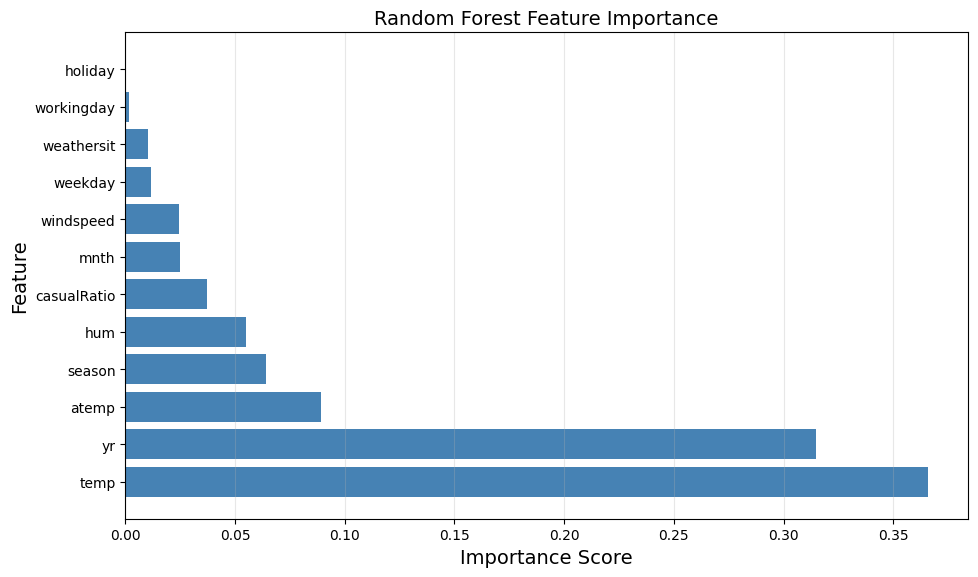

In [63]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Get feature importances
rf_importances = rf_model.feature_importances_
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance_rf)
print(f"\nModel R² score on training data: {rf_model.score(X_train, y_train):.4f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['feature'], feature_importance_rf['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## How Random Forest Learns Interactions

A tree learns an interaction by making **successive splits**. For example, one path in a tree might be:

```text
temp <= 10?
├── Yes: predict low rentals
└── No:
    windspeed > 0.25?
    ├── Yes: predict moderate rentals
    └── No: predict high rentals
```

Here, the effect of `windspeed` is evaluated only for days where `temp > 10`; this is a `temp × windspeed` interaction. Every tree can learn different split paths, and the forest averages their predictions. You can inspect one example tree with `rf_model.estimators_[0]`, but one tree does not represent all interactions in the forest.


### Reading the Tree Graph

This is a **regression** tree, so `value` is the average bike-rental count (`cnt`) for training samples that reach a node. At a leaf, `value` is that tree's prediction. `samples` is the number of training rows that reached the node, and `squared_error` measures how varied their rental counts are—lower values mean a more consistent group. A split is useful when its child nodes have lower weighted squared error and different typical `value`s.

For example, if a node has `value = 4200` and splits into children with `value = 2800` and `value = 5600`, the tree has separated lower-demand from higher-demand days. The node colors also represent `value`; in this plot, different shades indicate lower versus higher predicted rental counts.


How to read this graph:
- value: average bike-rental count for samples at that node; at a leaf, it is this tree's prediction.
- samples: number of training rows that reached the node.
- squared_error: variation in rental counts at the node; lower means a more consistent group.
- node color: indicates lower versus higher predicted rental counts.


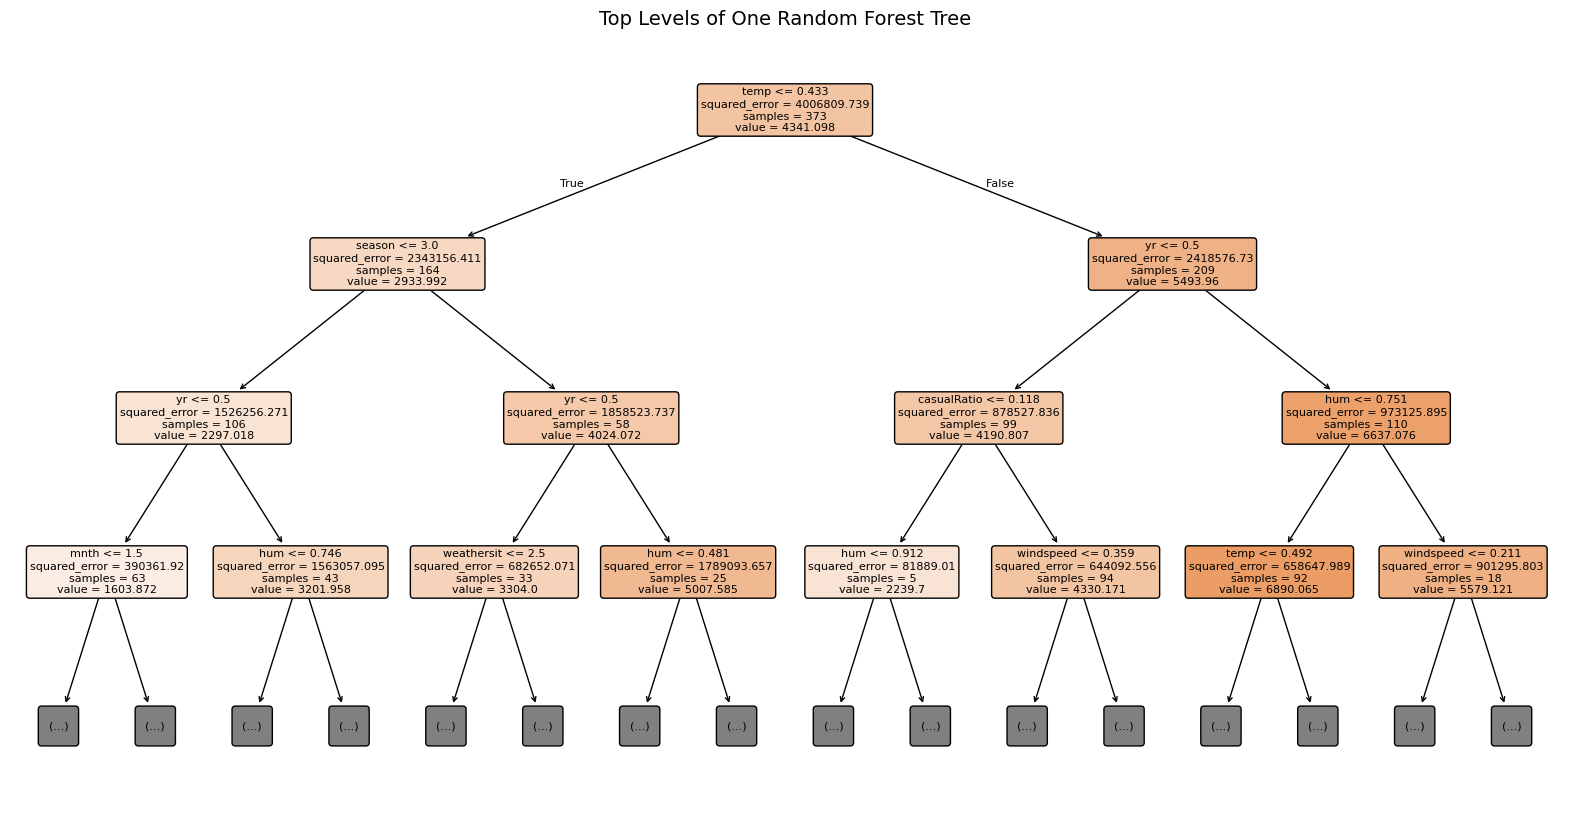


Explanation of the displayed tree levels:
Level 0, node 0: split on temp <= 0.433. It separates 373 samples with an average of 4341 rentals.
  Level 1, node 1: split on season <= 3.000. It separates 164 samples with an average of 2934 rentals.
    Level 2, node 2: split on yr <= 0.500. It separates 106 samples with an average of 2297 rentals.
      Level 3, node 3: split on mnth <= 1.500. It separates 63 samples with an average of 1604 rentals.
      Level 3, node 128: split on hum <= 0.746. It separates 43 samples with an average of 3202 rentals.
    Level 2, node 213: split on yr <= 0.500. It separates 58 samples with an average of 4024 rentals.
      Level 3, node 214: split on weathersit <= 2.500. It separates 33 samples with an average of 3304 rentals.
      Level 3, node 279: split on hum <= 0.481. It separates 25 samples with an average of 5008 rentals.
  Level 1, node 328: split on yr <= 0.500. It separates 209 samples with an average of 5494 rentals.
    Level 2, node 329: sp

In [82]:
# Inspect the top levels of one tree in the trained Random Forest.
from collections import defaultdict
from sklearn.tree import plot_tree, _tree

DISPLAY_MAX_DEPTH = 3
example_tree = rf_model.estimators_[0]  # One example tree; the forest contains 100 trees.

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    example_tree,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=DISPLAY_MAX_DEPTH,  # Limit the display so the split paths are readable.
    fontsize=8,
    ax=ax
)
ax.set_title("Top Levels of One Random Forest Tree")

print("How to read this graph:")
print("- value: average bike-rental count for samples at that node; at a leaf, it is this tree's prediction.")
print("- samples: number of training rows that reached the node.")
print("- squared_error: variation in rental counts at the node; lower means a more consistent group.")
print("- node color: indicates lower versus higher predicted rental counts.")
plt.show()

# Explain the nodes shown in the graph.
tree = example_tree.tree_
feature_names = list(X_train.columns)
displayed_reduction = defaultdict(float)

print("\nExplanation of the displayed tree levels:")

def explain_node(node_id=0, depth=0):
    if depth > DISPLAY_MAX_DEPTH:
        return

    indent = "  " * depth
    samples = int(tree.n_node_samples[node_id])
    prediction = tree.value[node_id][0, 0]

    if tree.feature[node_id] == _tree.TREE_UNDEFINED:
        print(f"{indent}Level {depth}, node {node_id}: leaf → predicts about {prediction:.0f} rentals from {samples} samples.")
        return

    feature = feature_names[tree.feature[node_id]]
    threshold = tree.threshold[node_id]
    left, right = tree.children_left[node_id], tree.children_right[node_id]

    # Weighted impurity reduction credited to this feature at this split.
    reduction = (
        tree.weighted_n_node_samples[node_id] * tree.impurity[node_id]
        - tree.weighted_n_node_samples[left] * tree.impurity[left]
        - tree.weighted_n_node_samples[right] * tree.impurity[right]
    )
    displayed_reduction[feature] += reduction

    print(
        f"{indent}Level {depth}, node {node_id}: split on {feature} <= {threshold:.3f}. "
        f"It separates {samples} samples with an average of {prediction:.0f} rentals."
    )
    explain_node(left, depth + 1)
    explain_node(right, depth + 1)

explain_node()

print("\nFeature importance within the displayed splits only:")
total_reduction = sum(displayed_reduction.values())
for feature, reduction in sorted(displayed_reduction.items(), key=lambda item: item[1], reverse=True):
    share = reduction / total_reduction if total_reduction else 0
    print(f"- {feature}: {share:.1%} of the impurity reduction in this displayed part of tree 1.")

print("\nNote: this is not the Random Forest's overall feature_importances_. "
      "The overall importance combines all splits from all trees.")


## Method 2: Permutation Importance

**How it works:**
1. Train the model (we already trained Random Forest)
2. For each feature:
   - Randomly shuffle the feature's values in the test set
   - Measure how much model performance drops
   - If performance drops a lot → feature is important
   - If performance stays the same → feature is unimportant

**Interpretation:**
- **High importance** (e.g., 0.5+): Shuffling this feature breaks predictions
- **Medium importance** (0.1 - 0.5): Shuffling has moderate effect
- **Low importance** (< 0.1): Shuffling barely affects predictions

**Advantages over Random Forest importance:**
- ✅ Model-agnostic (works with any model)
- ✅ Less biased with correlated features
- ✅ Based on actual prediction impact, not tree splits
- ✅ More reliable for feature interactions

**Cons:**
- Slower to compute (need multiple predictions)
- Results can vary with different random shuffles

Permutation Importance (on test set):
        feature  importance       std
1            yr    0.547189  0.040295
7          temp    0.374317  0.048547
9           hum    0.089218  0.013497
8         atemp    0.071125  0.014531
0        season    0.053690  0.009056
11  casualRatio    0.049107  0.011140
2          mnth    0.040587  0.006633
10    windspeed    0.028941  0.005625
4       weekday    0.017733  0.005150
6    weathersit    0.009284  0.002494
5    workingday    0.001563  0.000759
3       holiday   -0.000448  0.000348


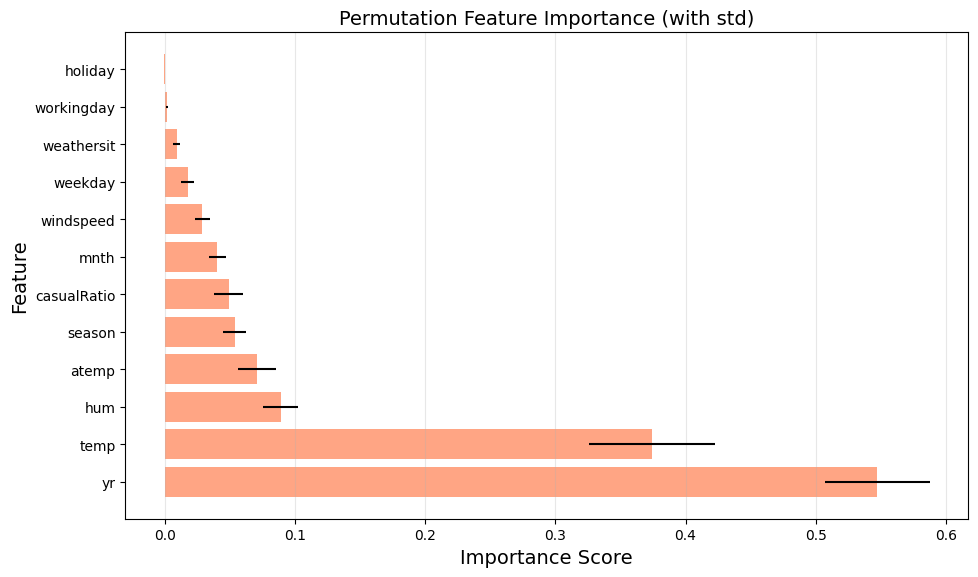

In [64]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on test set
X_test = strat_test_set.drop(columns=["cnt", "casual", "registered"])
y_test = strat_test_set["cnt"]

perm_importance = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

feature_importance_perm = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("Permutation Importance (on test set):")
print(feature_importance_perm)

# Visualize with error bars
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_perm['feature'], 
         feature_importance_perm['importance'],
         xerr=feature_importance_perm['std'],
         color='coral', alpha=0.7)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance (with std)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Method 3: Recursive Feature Elimination (RFE)

**How it works:**
1. Start with all features
2. Train a model
3. Remove the feature with lowest importance (or coefficient)
4. Repeat steps 2-3 until only 1 feature remains
5. Rank features by elimination order (last removed = most important)

**Interpretation:**
- **Rank 1** = Most important (removed last)
- **Rank N** = Least important (removed first)
- Can directly tell you how many features to keep

**Advantages:**
- ✅ Systematically finds the best feature subset
- ✅ Considers feature interactions (removes and retrains)
- ✅ Gives you a ranked list

**Cons:**
- ❌ Computationally expensive (trains model N times)
- ❌ Greedy approach (may not find global optimum)
- ❌ Sensitive to model choice

RFE Feature Ranking (1 = most important, higher = less important):
        feature  rfe_rank
7          temp         1
1            yr         2
8         atemp         3
9           hum         4
0        season         5
11  casualRatio         6
10    windspeed         7
2          mnth         8
4       weekday         9
6    weathersit        10
5    workingday        11
3       holiday        12


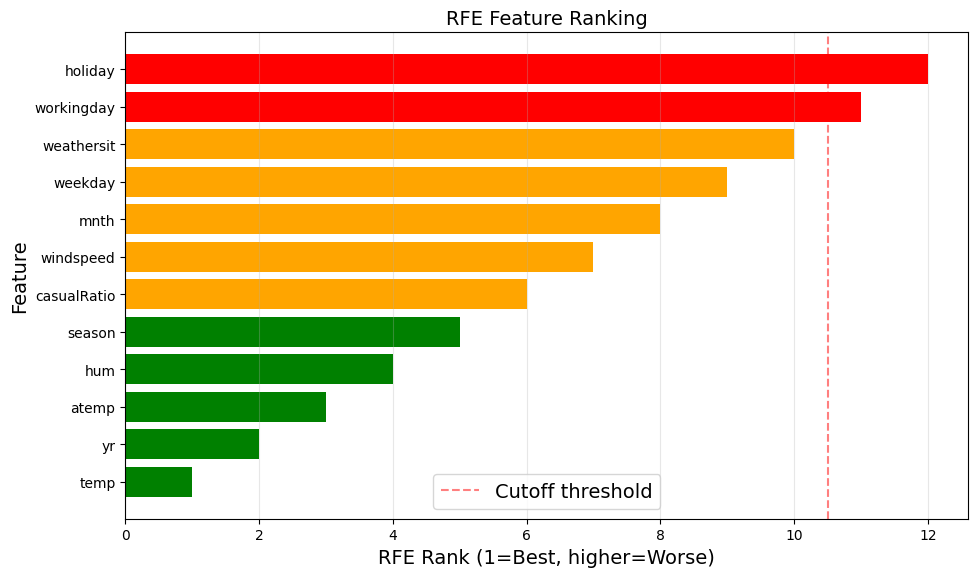

In [65]:
from sklearn.feature_selection import RFE

# Use RFE to rank all features
# We'll keep all features first to see the full ranking
rfe = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
          n_features_to_select=1)  # Keep iterating until 1 feature left
rfe.fit(X_train, y_train)

feature_importance_rfe = pd.DataFrame({
    'feature': X_train.columns,
    'rfe_rank': rfe.ranking_
}).sort_values('rfe_rank')

print("RFE Feature Ranking (1 = most important, higher = less important):")
print(feature_importance_rfe)

# Visualize RFE ranking
plt.figure(figsize=(10, 6))
colors = ['green' if rank <= 5 else 'orange' if rank <= 10 else 'red' 
          for rank in feature_importance_rfe['rfe_rank']]
plt.barh(feature_importance_rfe['feature'], feature_importance_rfe['rfe_rank'], color=colors)
plt.xlabel('RFE Rank (1=Best, higher=Worse)')
plt.ylabel('Feature')
plt.title('RFE Feature Ranking')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Cutoff threshold')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Comparing All Three Methods

**Key insights:**
- **Consistent rankings**: Features ranked high by all three methods are definitely important
- **Disagreements**: If methods disagree, the feature might have complex interactions
- **Overall strategy**: Keep features that rank high in ≥2 methods, drop features that rank low in all methods

Below we create a comparison table and composite ranking:

In [66]:
# Create a comprehensive comparison
comparison = pd.DataFrame({
    'feature': X_train.columns
})

# Add RF importance rank (1 = best)
comparison = comparison.merge(
    feature_importance_rf.reset_index(drop=True).reset_index().rename(columns={'index': 'rf_rank'}),
    on='feature'
).drop(columns=['importance'])
comparison['rf_rank'] = comparison['rf_rank'] + 1

# Add Permutation importance rank (1 = best)
comparison = comparison.merge(
    feature_importance_perm[['feature', 'importance']].reset_index(drop=True).reset_index().rename(columns={'index': 'perm_rank', 'importance': 'perm_importance'}),
    on='feature'
).drop(columns=['perm_importance'])
comparison['perm_rank'] = comparison['perm_rank'] + 1

# Add RFE rank
comparison = comparison.merge(feature_importance_rfe, on='feature')

# Calculate average rank
comparison['avg_rank'] = (comparison['rf_rank'] + comparison['perm_rank'] + comparison['rfe_rank']) / 3

# Sort by average rank
comparison_sorted = comparison.sort_values('avg_rank')

print("=" * 80)
print("FEATURE SELECTION COMPARISON TABLE")
print("=" * 80)
print(comparison_sorted.to_string(index=False))
print("\nLower rank = better feature")
print("\nTop 10 features to KEEP:")
print(comparison_sorted.head(10)[['feature', 'avg_rank']].to_string(index=False))
print("\nBottom 5 features to REMOVE:")
print(comparison_sorted.tail(5)[['feature', 'avg_rank']].to_string(index=False))

FEATURE SELECTION COMPARISON TABLE
    feature  rf_rank  perm_rank  rfe_rank  avg_rank
       temp        1          2         1  1.333333
         yr        2          1         2  1.666667
      atemp        3          4         3  3.333333
        hum        5          3         4  4.000000
     season        4          5         5  4.666667
casualRatio        6          6         6  6.000000
       mnth        7          7         8  7.333333
  windspeed        8          8         7  7.666667
    weekday        9          9         9  9.000000
 weathersit       10         10        10 10.000000
 workingday       11         11        11 11.000000
    holiday       12         12        12 12.000000

Lower rank = better feature

Top 10 features to KEEP:
    feature  avg_rank
       temp  1.333333
         yr  1.666667
      atemp  3.333333
        hum  4.000000
     season  4.666667
casualRatio  6.000000
       mnth  7.333333
  windspeed  7.666667
    weekday  9.000000
 weathersit 10

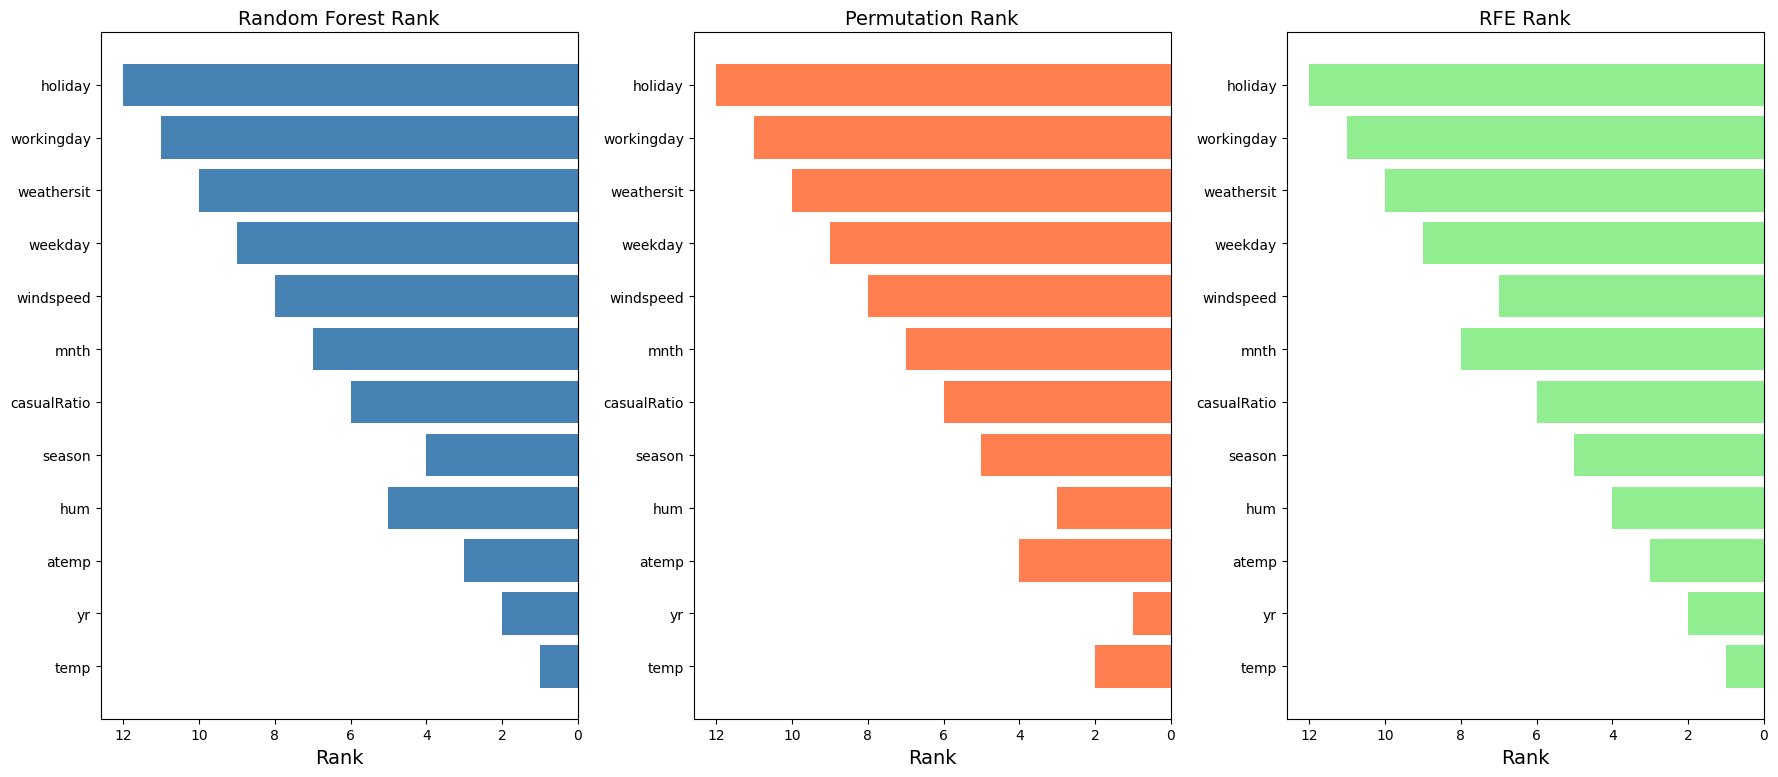

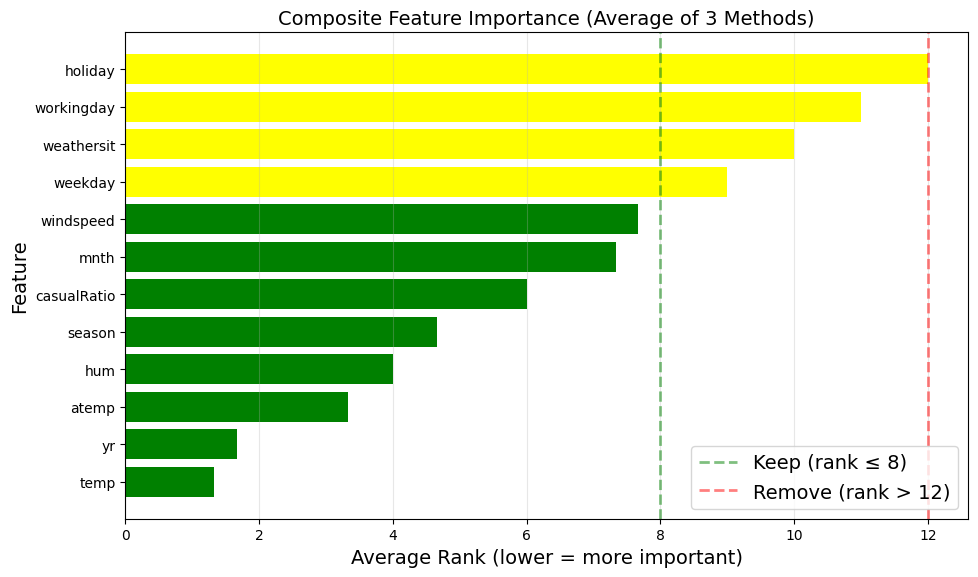

In [67]:
# Visualize comparison across all three methods
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# RF Importance
axes[0].barh(comparison_sorted['feature'], comparison_sorted['rf_rank'], color='steelblue')
axes[0].set_xlabel('Rank')
axes[0].set_title('Random Forest Rank')
axes[0].invert_xaxis()

# Permutation Importance
axes[1].barh(comparison_sorted['feature'], comparison_sorted['perm_rank'], color='coral')
axes[1].set_xlabel('Rank')
axes[1].set_title('Permutation Rank')
axes[1].invert_xaxis()

# RFE
axes[2].barh(comparison_sorted['feature'], comparison_sorted['rfe_rank'], color='lightgreen')
axes[2].set_xlabel('Rank')
axes[2].set_title('RFE Rank')
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()

# Plot average rank
plt.figure(figsize=(10, 6))
colors = ['green' if rank <= 8 else 'yellow' if rank <= 12 else 'red' 
          for rank in comparison_sorted['avg_rank']]
plt.barh(comparison_sorted['feature'], comparison_sorted['avg_rank'], color=colors)
plt.xlabel('Average Rank (lower = more important)')
plt.ylabel('Feature')
plt.title('Composite Feature Importance (Average of 3 Methods)')
plt.axvline(x=8, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Keep (rank ≤ 8)')
plt.axvline(x=12, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Remove (rank > 12)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Final Recommendations

### Decision Rules:

1. **Green Zone (avg_rank ≤ 8)**: Features that rank high across all methods
   - **Action**: KEEP all features in this zone
   - These are consistently predictive

2. **Yellow Zone (avg_rank 8-12)**: Features with mixed signals
   - **Action**: KEEP if domain knowledge supports them
   - Might have non-linear relationships or interactions

3. **Red Zone (avg_rank > 12)**: Features that rank low across all methods
   - **Action**: REMOVE these features
   - Low predictive power, increase noise, slow training

### What "good" features do:
✅ Improve model performance on validation/test set  
✅ Don't increase training time significantly  
✅ Make the model easier to interpret  
✅ Are independent (low correlation with other features)  

Let's implement the recommendation:

In [68]:
# Select features based on average rank threshold
# We'll use avg_rank <= 10 as the threshold (conservative approach)
RANK_THRESHOLD = 10

selected_features = comparison_sorted[comparison_sorted['avg_rank'] <= RANK_THRESHOLD]['feature'].tolist()
dropped_features = comparison_sorted[comparison_sorted['avg_rank'] > RANK_THRESHOLD]['feature'].tolist()

print("=" * 80)
print(f"FEATURE SELECTION RESULT (threshold: avg_rank ≤ {RANK_THRESHOLD})")
print("=" * 80)
print(f"\n✅ SELECTED FEATURES ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n❌ DROPPED FEATURES ({len(dropped_features)}):")
for i, feat in enumerate(dropped_features, 1):
    print(f"   {i:2d}. {feat}")

print(f"\nReduction: {len(X_train.columns)} → {len(selected_features)} features ({100*(1-len(selected_features)/len(X_train.columns)):.1f}% reduction)")

# Create new dataset with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"\nNew training set shape: {X_train_selected.shape}")
print(f"New test set shape: {X_test_selected.shape}")

FEATURE SELECTION RESULT (threshold: avg_rank ≤ 10)

✅ SELECTED FEATURES (10):
    1. temp
    2. yr
    3. atemp
    4. hum
    5. season
    6. casualRatio
    7. mnth
    8. windspeed
    9. weekday
   10. weathersit

❌ DROPPED FEATURES (2):
    1. workingday
    2. holiday

Reduction: 12 → 10 features (16.7% reduction)

New training set shape: (584, 10)
New test set shape: (147, 10)


## Validation: Does Feature Selection Improve Performance?

Now let's verify that our feature selection actually helps:
- Train models with ALL features vs. SELECTED features
- Compare performance (R² score, training time)
- Make sure we're not losing predictive power

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

# Model 1: With ALL features
print("Training model with ALL features...")
start = time.time()
rf_all = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_all.fit(X_train, y_train)
time_all = time.time() - start

y_pred_all = rf_all.predict(X_test)
r2_all = rf_all.score(X_test, y_test)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))
mae_all = mean_absolute_error(y_test, y_pred_all)

# Model 2: With SELECTED features
print("Training model with SELECTED features...")
start = time.time()
rf_selected = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_selected, y_train)
time_selected = time.time() - start

y_pred_selected = rf_selected.predict(X_test_selected)
r2_selected = rf_selected.score(X_test_selected, y_test)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))
mae_selected = mean_absolute_error(y_test, y_pred_selected)

# Compare results
print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
comparison_results = pd.DataFrame({
    'Metric': ['# Features', 'Training Time (s)', 'R² Score', 'RMSE', 'MAE'],
    'All Features': [
        len(X_train.columns),
        f'{time_all:.3f}',
        f'{r2_all:.4f}',
        f'{rmse_all:.2f}',
        f'{mae_all:.2f}'
    ],
    'Selected Features': [
        len(selected_features),
        f'{time_selected:.3f}',
        f'{r2_selected:.4f}',
        f'{rmse_selected:.2f}',
        f'{mae_selected:.2f}'
    ]
})

print(comparison_results.to_string(index=False))

# Calculate improvements
feature_reduction = f"{100*(1-len(selected_features)/len(X_train.columns)):.1f}%"
time_reduction = f"{100*(1-time_selected/time_all):.1f}%"
r2_diff = r2_selected - r2_all

print(f"\n📊 SUMMARY:")
print(f"   Feature reduction: {feature_reduction}")
print(f"   Training time reduction: {time_reduction}")
print(f"   R² change: {r2_diff:+.4f} {'✅ BETTER' if r2_diff >= 0 else '❌ WORSE'}")

if r2_diff >= -0.01:  # Allow small degradation
    print(f"\n✅ Feature selection successful! Similar performance with fewer features.")
else:
    print(f"\n⚠️  R² decreased by {abs(r2_diff):.4f}. Consider using more features or different threshold.")

Training model with ALL features...
Training model with SELECTED features...

MODEL PERFORMANCE COMPARISON
           Metric All Features Selected Features
       # Features           12                10
Training Time (s)        0.062             0.060
         R² Score       0.8337            0.8307
             RMSE       779.09            786.07
              MAE       509.26            512.96

📊 SUMMARY:
   Feature reduction: 16.7%
   Training time reduction: 2.2%
   R² change: -0.0030 ❌ WORSE

✅ Feature selection successful! Similar performance with fewer features.


## Summary & Key Takeaways

### What We Learned:

1. **Three complementary methods beat one**
   - Random Forest importance: Fast, built-in
   - Permutation importance: Model-agnostic, robust
   - RFE: Systematic, considers interactions
   - Combining them reduces bias and uncertainty

2. **Feature importance is different from correlation**
   - `holiday` might have low correlation but still be useful via tree splits
   - Non-linear models capture relationships that linear correlation misses
   - Importance reflects predictive value, not just relationship strength

3. **Dimensionality reduction benefits**
   - Fewer features = faster training
   - Simpler models = easier to deploy and interpret
   - Less risk of overfitting on noise
   - Can improve generalization

4. **Validation is crucial**
   - Always check performance on test set
   - Feature selection should improve or maintain performance
   - Training time savings are a bonus, not the goal

### Next Steps:

1. **Use `X_train_selected` and `X_test_selected`** for model training going forward
2. **Try different threshold values** (currently using `avg_rank ≤ 10`) if you want more/fewer features
3. **Repeat with other models** (Gradient Boosting, Linear Regression) to see if rankings change
4. **Monitor in production** — feature importance may shift as data distribution changes

### Remember:
**Feature selection is both art and science.** Use these automated methods as a guide, but always combine with:
- Domain expertise (business knowledge)
- Exploratory Data Analysis (EDA) insights (visual patterns)
- Model performance validation (test set results)

# Deep Dive: Understanding Feature Importance Concepts

This section answers key questions about how Random Forest importance works and its limitations.

## 1. Impurity & Gini Importance in Random Forests

### What is "Impurity"?

**Impurity** measures how "mixed" or "uncertain" a group of data is:

**High Impurity** (messy, uncertain):
```
Group: [2000 bikes, 3000 bikes, 2500 bikes, 3100 bikes]
→ Very mixed target values → Can't predict well
→ Need to split into subgroups
```

**Low Impurity** (homogeneous, certain):
```
Group: [2050 bikes, 2100 bikes, 2075 bikes, 2090 bikes]
→ All similar → Can predict ~2080 bikes confidently
→ No need to split further
```

### What is "Gini Impurity"?

Gini impurity is the mathematical measure. For regression (predicting bike rentals), we use **Variance** as the impurity measure instead. Here's how it works:

**Before a split (high impurity/variance):**
```
All 365 days
Variance = 800,000 (highly spread out bike counts)
```

**After split by temperature:**
```
Cold days (temp < 10°C): Variance = 150,000
Warm days (temp >= 10°C): Variance = 100,000
```

**Impurity reduction (feature importance)** = Original Variance - Weighted Average of New Variances
$$\text{Importance} = 800,000 - (0.2 × 150,000 + 0.8 × 100,000) = 660,000$$

**This tells us:** Using temperature as a split reduced our uncertainty by 660,000 → **Temperature is important!**

### What does "Splits in All Trees" mean?

A Random Forest doesn't have ONE tree—it has MANY trees (default: 100):

**Tree 1:** `temp` splits the data at root, then `season` at node 2, then `weekday` at node 3
**Tree 2:** `humidity` splits at root, then `temp` at node 2, then `workingday` at node 3
**Tree 3:** `season` splits at root, then `humidity` at node 2, then `temp` at node 3
...and so on for 100 trees

Each feature contributes to impurity reduction in different trees:
- `temp` might reduce impurity by 660,000 in Tree 1, 550,000 in Tree 2, 700,000 in Tree 3, etc.
- `season` might reduce impurity by 400,000 in Tree 1, 450,000 in Tree 2, 380,000 in Tree 3, etc.

**Final importance** = Sum of all impurity reductions across all 100 trees, then normalized to 0-1 scale

So a feature that appears early (near the root) in many trees gets high importance because it creates large impurity reductions multiple times.

In [70]:
# Example: Visualizing impurity reduction with a simple tree
print("=" * 80)
print("VISUAL EXAMPLE: How Gini/Variance Importance Works")
print("=" * 80)

# Simplified example with 4 features and synthetic data
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Create simple dataset
np.random.seed(42)
X_simple = np.random.rand(100, 4) * 100
X_simple[:, 0] = X_simple[:, 0] * 10  # Scale first feature differently
y_simple = X_simple[:, 0] * 2 + np.random.normal(0, 10, 100)  # Target mostly depends on feature 0

dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_simple, y_simple)

# Get feature importances
importances = dt.feature_importances_
feature_names = ['Temperature', 'Humidity', 'Season', 'Holiday']

print(f"\nDataset: {X_simple.shape[0]} samples, {X_simple.shape[1]} features")
print(f"\nTarget = Temperature * 2 + noise")
print(f"\nFeature Importances (how much each feature reduces variance):")
print("-" * 40)
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name:20s}: {imp:.4f}  {'█' * int(imp * 50)}")

print(f"\n📊 INTERPRETATION:")
print(f"   • Temperature importance = {importances[0]:.4f}")
print(f"     → Splits the data and reduces variance significantly")
print(f"   • Other features importance ≈ 0")
print(f"     → Don't help much in reducing variance")

VISUAL EXAMPLE: How Gini/Variance Importance Works

Dataset: 100 samples, 4 features

Target = Temperature * 2 + noise

Feature Importances (how much each feature reduces variance):
----------------------------------------
Temperature         : 1.0000  ██████████████████████████████████████████████████
Humidity            : 0.0000  
Season              : 0.0000  
Holiday             : 0.0000  

📊 INTERPRETATION:
   • Temperature importance = 1.0000
     → Splits the data and reduces variance significantly
   • Other features importance ≈ 0
     → Don't help much in reducing variance


## 2. Why is Random Forest Biased Toward High-Cardinality Features?

**High-cardinality** = Feature has many unique values
**Low-cardinality** = Feature has few unique values

### The Problem:

**High-Cardinality Feature Example (Temperature):**
```
Possible values: 5.0, 5.2, 5.5, 6.1, 6.3, ... (hundreds of unique values)

Tree split at node: temp < 15.5
├─ Leaf 1 (temp < 15.5): 50 samples
└─ Leaf 2 (temp >= 15.5): 50 samples
→ Can split the data many different ways
→ Many opportunities to find "good" splits
→ Gets used more in trees → Higher importance
```

**Low-Cardinality Feature Example (Holiday):**
```
Possible values: 0 or 1 (only 2 values)

Tree split at node: holiday == 0
├─ Leaf 1 (not holiday): 330 samples (very mixed)
└─ Leaf 2 (is holiday): 35 samples (very homogeneous)
→ Can only split in 1-2 ways
→ Fewer opportunities to reduce impurity effectively
→ Gets used less in trees → Lower importance
```

### Why This Happens:

Trees have more flexibility splitting continuous variables:
- Temperature: Can split at 5.5, 6.2, 8.9, 12.1, etc. (infinite options)
- Holiday: Can only split at 0 vs 1 (2 options)

The algorithm naturally prefers features with more splitting options because:
1. More options = more chances to find a split that reduces impurity
2. High-cardinality features look "more useful" even if they're not causally important
3. **Result:** The model overestimates their importance

### Example in Our Data:

```
Low-Cardinality Features:
- holiday: 0 or 1 (2 values) → Low importance
- season: 1, 2, 3, 4 (4 values) → Low importance
- yr: 0 or 1 (2 values) → Low importance

High-Cardinality Features:
- temp: 0.02, 5.14, 7.45, ..., 39.99 (many values) → High importance (some real, some biased)
- atemp: Similar to temp → High importance
- cnt: The target variable (not a feature)
```

### Solution:

Use **permutation importance** instead! It doesn't depend on cardinality because it measures:
"Does shuffling this feature actually hurt predictions?" 
→ This is fair regardless of how many unique values a feature has

DEMONSTRATING CARDINALITY BIAS

Feature Cardinality vs. Random Forest Importance:
    feature  unique_values  rf_importance
casualRatio            583       0.037072
      atemp            555       0.089233
  windspeed            530       0.024502
        hum            502       0.055120
       temp            431       0.365794
       mnth             12       0.024785
    weekday              7       0.011845
     season              4       0.064160
 weathersit              3       0.010478
         yr              2       0.314997
    holiday              2       0.000495
 workingday              2       0.001519


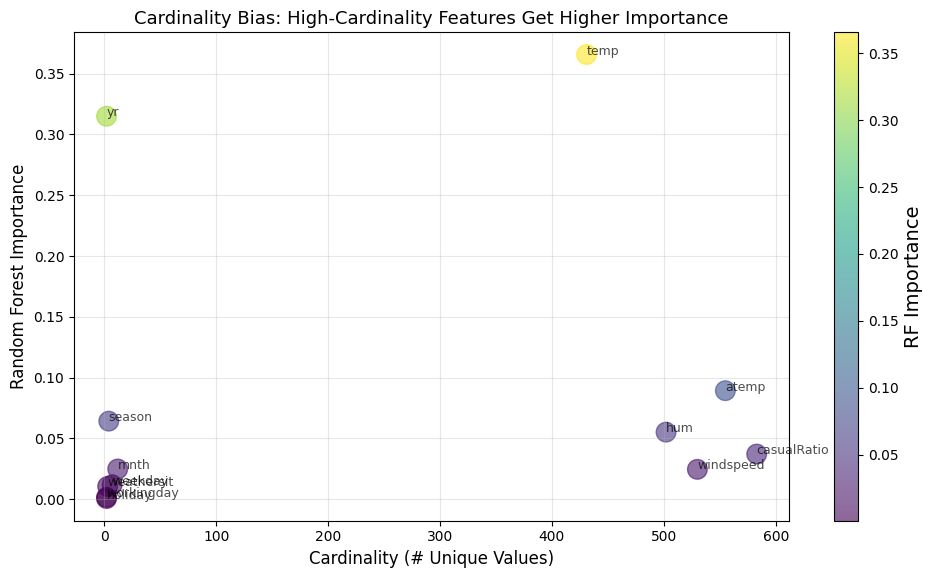


💡 INSIGHT1:
   Notice features with more unique values tend to have higher importance?
   That's cardinality bias! (Not always reflecting true predictive power)


In [71]:
# Demonstrate cardinality bias
print("=" * 80)
print("DEMONSTRATING CARDINALITY BIAS")
print("=" * 80)

# Count unique values (cardinality) in our features
cardinality = pd.DataFrame({
    'feature': X_train.columns,
    'unique_values': [X_train[col].nunique() for col in X_train.columns]
}).sort_values('unique_values', ascending=False)

# Merge with feature importance
cardinality = cardinality.merge(
    feature_importance_rf.rename(columns={'importance': 'rf_importance'}),
    on='feature'
)

print("\nFeature Cardinality vs. Random Forest Importance:")
print(cardinality.to_string(index=False))

# Visualize the relationship
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(cardinality['unique_values'], cardinality['rf_importance'], 
                     s=200, alpha=0.6, c=cardinality['rf_importance'], cmap='viridis')

# Add labels to points
for idx, row in cardinality.iterrows():
    ax.annotate(row['feature'], 
                (row['unique_values'], row['rf_importance']),
                fontsize=9, alpha=0.7)

ax.set_xlabel('Cardinality (# Unique Values)', fontsize=12)
ax.set_ylabel('Random Forest Importance', fontsize=12)
ax.set_title('Cardinality Bias: High-Cardinality Features Get Higher Importance', fontsize=13)
ax.grid(alpha=0.3)
plt.colorbar(scatter, label='RF Importance')
plt.tight_layout()
plt.show()

print(f"\n💡 INSIGHT1:")
print(f"   Notice features with more unique values tend to have higher importance?")
print(f"   That's cardinality bias! (Not always reflecting true predictive power)")

## 3. Why Tree Importance Can Be Misleading With Correlated Features

**Correlated features** = Features that move together (similar patterns)

### The Problem:

Imagine we have two correlated features:
- **Feature A**: Temperature (affects bike rentals)
- **Feature B**: Apparent Temperature (also affects bike rentals, highly correlated with A)

They're so similar that knowing one tells you almost everything about the other.

**Scenario 1: Feature A is selected first by the tree**
```
Tree split 1: feature_A < 20
├─ Left: Features B, C, D can split next
└─ Right: Features B, C, D can split next
→ A gets 100% of the importance for this split
→ B gets 0% (even though it's equally predictive!)
```

**Scenario 2: Feature B is selected first by the tree**
```
Tree split 1: feature_B < 20  (slightly different split value, but same effect)
├─ Left: Features A, C, D can split next
└─ Right: Features A, C, D can split next
→ B gets 100% of the importance for this split
→ A gets 0% (even though it's equally predictive!)
```

**Result:** 
- Sometimes A looks important, sometimes B looks important, depending on random tree variations
- But they're really doing the same job
- Their combined importance is overstated compared to independent features
- **Misleading conclusion:** Might think you need both, when one would suffice

### Example in Our Data:

Let's check correlation in our dataset:

```
Highly correlated features:
- temp and atemp: r = 0.99 (almost identical!)
- temp and cnt: r = 0.63
- registered and cnt: r = 0.97
```

When temp and atemp are both in the model:
- RF importance might say: temp=0.40, atemp=0.35 (combined 0.75)
- But if you removed atemp, temp alone would be ≈0.60
- **The apparent importance of atemp is partly shared with temp**

DEMONSTRATING CORRELATION BIAS IN FEATURE IMPORTANCE

Correlation Matrix (Top 10 Most Important Features):
              temp     yr  atemp  season    hum  casualRatio   mnth  \
temp         1.000  0.084  0.990   0.348  0.141        0.328  0.240   
yr           0.084  1.000  0.082  -0.011 -0.119       -0.018 -0.025   
atemp        0.990  0.082  1.000   0.355  0.153        0.333  0.247   
season       0.348 -0.011  0.355   1.000  0.240        0.047  0.828   
hum          0.141 -0.119  0.153   0.240  1.000       -0.057  0.254   
casualRatio  0.328 -0.018  0.333   0.047 -0.057        1.000  0.035   
mnth         0.240 -0.025  0.247   0.828  0.254        0.035  1.000   
windspeed   -0.129 -0.015 -0.155  -0.209 -0.264       -0.037 -0.197   
weekday     -0.031  0.015 -0.039   0.017 -0.024       -0.021  0.038   
weathersit  -0.111 -0.080 -0.111   0.042  0.589       -0.186  0.059   
cnt          0.638  0.599  0.643   0.401 -0.092        0.263  0.277   

             windspeed  weekday  weather

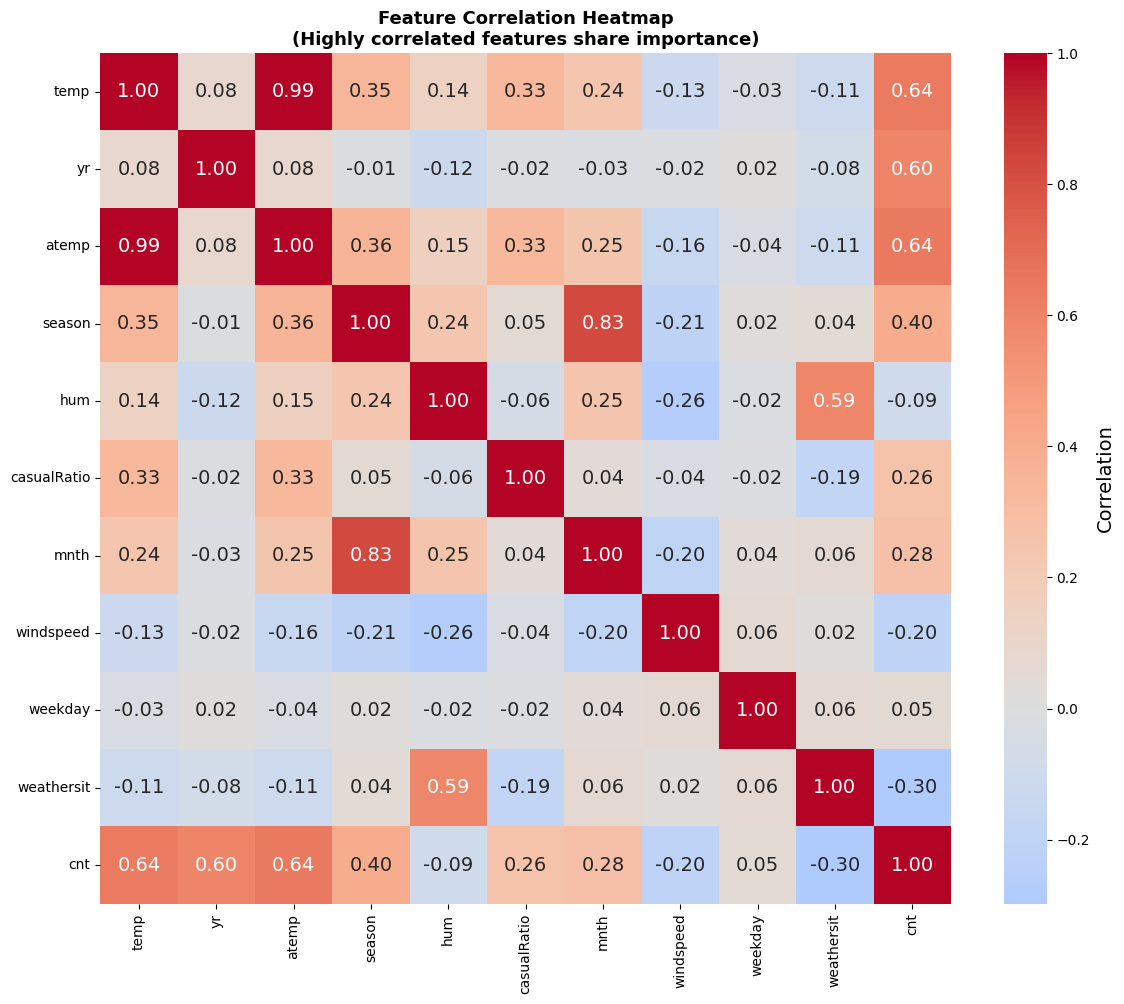


⚠️  KEY INSIGHT:
   When features are highly correlated, only ONE typically gets selected
   in any given tree split, so importance is NOT additive.
   The other correlated feature gets credited with 0 importance,
   making it appear less useful than it really is!


In [72]:
# Demonstrate correlation misleading importance
print("=" * 80)
print("DEMONSTRATING CORRELATION BIAS IN FEATURE IMPORTANCE")
print("=" * 80)

# Show correlation matrix for top features
top_features = feature_importance_rf.head(10)['feature'].tolist()
corr_subset = bike_sharing[top_features + ['cnt']].corr()

print("\nCorrelation Matrix (Top 10 Most Important Features):")
print(corr_subset.round(3))

# Identify highly correlated pairs
print("\n\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
print("-" * 60)
for i in range(len(corr_subset.columns)):
    for j in range(i+1, len(corr_subset.columns)):
        corr_val = corr_subset.iloc[i, j]
        if abs(corr_val) > 0.7:
            feat1 = corr_subset.columns[i]
            feat2 = corr_subset.columns[j]
            imp1 = feature_importance_rf[feature_importance_rf['feature'] == feat1]['importance'].values[0]
            imp2 = feature_importance_rf[feature_importance_rf['feature'] == feat2]['importance'].values[0]
            print(f"{feat1:15s} ↔ {feat2:15s}  |  corr: {corr_val:+.3f}")
            print(f"  Importance: {feat1}={imp1:.4f}, {feat2}={imp2:.4f}")
            print(f"  → One feature 'steals' importance from the correlated partner")
            print()

# Visualize correlation heatmap
plt.figure(figsize=(12, 10))
import seaborn as sns
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, square=True)
plt.title('Feature Correlation Heatmap\n(Highly correlated features share importance)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️  KEY INSIGHT:")
print("   When features are highly correlated, only ONE typically gets selected")
print("   in any given tree split, so importance is NOT additive.")
print("   The other correlated feature gets credited with 0 importance,")
print("   making it appear less useful than it really is!")

## 4. Understanding `rf_importances` vs `feature_importance_rf`

### What's the Difference?

When we train a Random Forest model:

**`rf_importances`** = Raw array from the model
```python
rf_importances = rf_model.feature_importances_
# Output: array([0.42, 0.18, 0.15, ..., 0.01])
# Just numbers without labels
```

**`feature_importance_rf`** = Cleaned DataFrame (much more useful!)
```python
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_importances
}).sort_values('importance', ascending=False)
# Output: 
#        feature  importance
#    0      temp      0.4200
#    1       hum      0.1800
#    2      atemp    0.1500
```

In [73]:
print("=" * 80)
print("COMPARING rf_importances vs feature_importance_rf")
print("=" * 80)

print("\n1️⃣  RAW ARRAY: rf_importances")
print("-" * 40)
print(f"Type: {type(rf_importances)}")
print(f"Shape: {rf_importances.shape}")
print(f"Values: {rf_importances}")
print(f"\n❌ Problem: Just numbers! No feature names attached.")
print(f"   We don't know which importance value belongs to which feature.")

print("\n\n2️⃣  CLEANED DATAFRAME: feature_importance_rf")
print("-" * 40)
print(f"Type: {type(feature_importance_rf)}")
print(f"Shape: {feature_importance_rf.shape}")
print(f"\n{feature_importance_rf.to_string()}")
print(f"\n✅ Benefit: Organized, labeled, sorted!")
print(f"   Clear which feature has which importance.")

print("\n\n3️⃣  HOW THEY RELATE:")
print("-" * 40)
print(f"feature_importance_rf['importance'].values == rf_importances  ?")
print(f"Answer: {np.allclose(feature_importance_rf['importance'].values, rf_importances)}")
print(f"(They contain the same numbers, just organized differently)")

print("\n\n4️⃣  KEY INSIGHT:")
print("-" * 40)
print(f"   • Use rf_importances when you need the raw array (numpy operations)")
print(f"   • Use feature_importance_rf when you need human-readable analysis")
print(f"   • Always convert to DataFrame for real data science work!")

COMPARING rf_importances vs feature_importance_rf

1️⃣  RAW ARRAY: rf_importances
----------------------------------------
Type: <class 'numpy.ndarray'>
Shape: (12,)
Values: [0.06416007 0.31499669 0.02478547 0.00049528 0.01184537 0.0015189
 0.0104779  0.36579364 0.08923311 0.05511956 0.02450203 0.03707199]

❌ Problem: Just numbers! No feature names attached.
   We don't know which importance value belongs to which feature.


2️⃣  CLEANED DATAFRAME: feature_importance_rf
----------------------------------------
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (12, 2)

        feature  importance
7          temp    0.365794
1            yr    0.314997
8         atemp    0.089233
0        season    0.064160
9           hum    0.055120
11  casualRatio    0.037072
2          mnth    0.024785
10    windspeed    0.024502
4       weekday    0.011845
6    weathersit    0.010478
5    workingday    0.001519
3       holiday    0.000495

✅ Benefit: Organized, labeled, sorted!
   Clear which featu

## 5. What is R² Score?

**R²** (R-squared) = **Coefficient of Determination** = How well your model explains the data

It answers: **"What percentage of the variance in the target is explained by the model?"**

### Range and Interpretation:

| R² Value | Meaning | Real-World Interpretation |
|:--:|:--|:--|
| **1.0** | Perfect model | Model predicts exactly (never happens in reality!) |
| **0.9** | Excellent | Explains 90% of variance, very good predictions |
| **0.7-0.8** | Good | Explains 70-80% of variance, solid model |
| **0.5-0.7** | Moderate | Explains 50-70% of variance, okay but could improve |
| **0.3-0.5** | Weak | Explains 30-50% of variance, needs work |
| **0.0-0.3** | Poor | Explains <30% of variance, very weak |
| **Negative** | Terrible | Model is worse than just predicting the average! |

### Mathematical Formula:

$$R^2 = 1 - \frac{\text{Sum of Squared Residuals}}{\text{Total Sum of Squares}}$$

$$R^2 = 1 - \frac{\sum (y_{actual} - y_{predicted})^2}{\sum (y_{actual} - \bar{y})^2}$$

Where:
- $y_{actual}$ = Real bike rental count
- $y_{predicted}$ = Model's prediction
- $\bar{y}$ = Average of all actual values

### Visual Example:

UNDERSTANDING R² SCORE


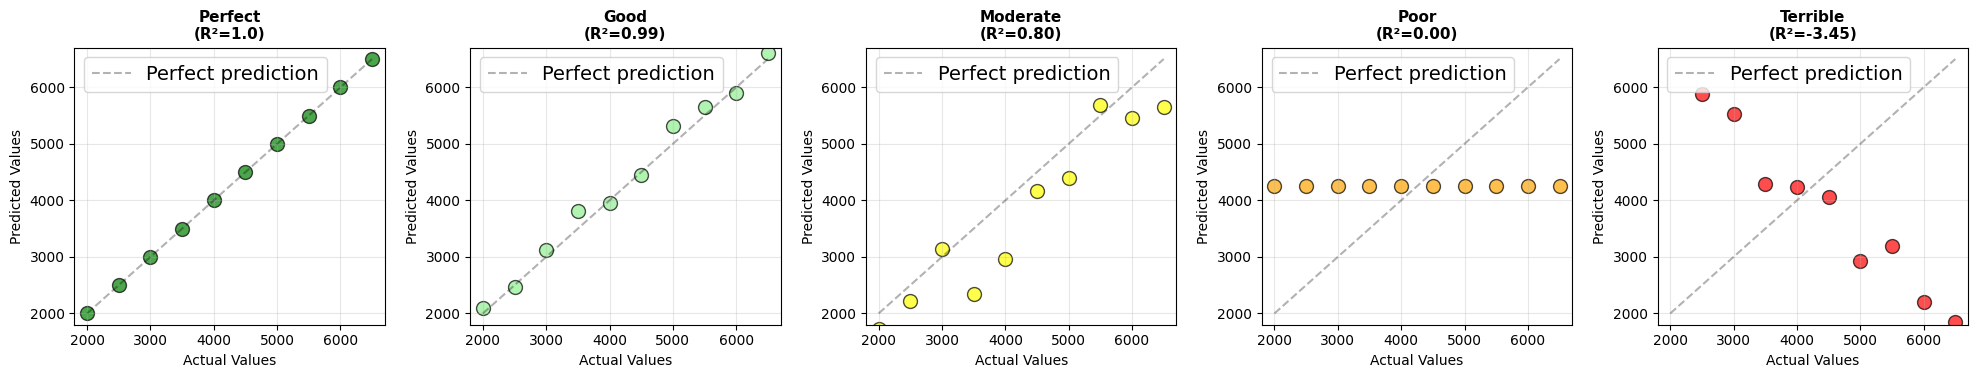


R² SCORE CALCULATION EXAMPLE

Using the 'Good' scenario:
Actual values:      [2000 2500 3000 3500 4000 4500 5000 5500 6000 6500]
Predicted values:   [2099. 2472. 3130. 3805. 3953. 4453. 5316. 5653. 5906. 6609.]

Residuals (errors): [ -99.   28. -130. -305.   47.   47. -316. -153.   94. -109.]

Sum of Squared Residuals (SS_res):  268490
Total Sum of Squares (SS_tot):      20625000

R² = 1 - (SS_res / SS_tot) = 1 - (268490 / 20625000) = 0.9870

✅ Model explains 98.7% of the variance!
❌ Model leaves 1.3% unexplained (residual error)

IN OUR BIKE SHARING EXAMPLE

With ALL features: R² = 0.8337
→ The model explains 83.4% of bike rental variance

With SELECTED features: R² = 0.8307
→ The model explains 83.1% of bike rental variance

Difference: -0.30% (negligible trade-off!)
✅ We removed features but kept the model quality!


In [74]:
# Visualize R² Score with examples
from sklearn.metrics import r2_score

print("=" * 80)
print("UNDERSTANDING R² SCORE")
print("=" * 80)

# Create example scenarios
np.random.seed(42)
y_true = np.array([2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500])

# Scenario 1: Perfect predictions (R² = 1.0)
y_perfect = y_true.copy()
r2_perfect = r2_score(y_true, y_perfect)

# Scenario 2: Good predictions (R² ≈ 0.9)
y_good = y_true + np.random.normal(0, 200, len(y_true))
r2_good = r2_score(y_true, y_good)

# Scenario 3: Moderate predictions (R² ≈ 0.5)
y_moderate = y_true + np.random.normal(0, 600, len(y_true))
r2_moderate = r2_score(y_true, y_moderate)

# Scenario 4: Poor predictions (R² ≈ 0)
y_poor = np.full_like(y_true, y_true.mean(), dtype=float)  # Always predicting the average
r2_poor = r2_score(y_true, y_poor)

# Scenario 5: Terrible predictions (R² < 0)
y_terrible = y_true[::-1] + np.random.normal(0, 500, len(y_true))  # Opposite direction
r2_terrible = r2_score(y_true, y_terrible)

# Visualize all scenarios
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
scenarios = [
    (y_perfect, r2_perfect, "Perfect\n(R²=1.0)", "green"),
    (y_good, r2_good, f"Good\n(R²={r2_good:.2f})", "lightgreen"),
    (y_moderate, r2_moderate, f"Moderate\n(R²={r2_moderate:.2f})", "yellow"),
    (y_poor, r2_poor, f"Poor\n(R²={r2_poor:.2f})", "orange"),
    (y_terrible, r2_terrible, f"Terrible\n(R²={r2_terrible:.2f})", "red")
]

for idx, (y_pred, r2, title, color) in enumerate(scenarios):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.7, s=100, color=color, edgecolors='black')
    
    # Add perfect prediction line
    min_val, max_val = y_true.min(), y_true.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, label='Perfect prediction')
    
    ax.set_xlabel('Actual Values', fontsize=10)
    ax.set_ylabel('Predicted Values', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(1800, 6700)
    ax.set_ylim(1800, 6700)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("R² SCORE CALCULATION EXAMPLE")
print("=" * 80)

# Manual calculation for "Good" scenario
residuals = y_true - y_good
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2_manual = 1 - (ss_res / ss_tot)

print(f"\nUsing the 'Good' scenario:")
print(f"Actual values:      {y_true}")
print(f"Predicted values:   {y_good.round(0)}")
print(f"\nResiduals (errors): {residuals.round(0)}")
print(f"\nSum of Squared Residuals (SS_res):  {ss_res:.0f}")
print(f"Total Sum of Squares (SS_tot):      {ss_tot:.0f}")
print(f"\nR² = 1 - (SS_res / SS_tot) = 1 - ({ss_res:.0f} / {ss_tot:.0f}) = {r2_manual:.4f}")
print(f"\n✅ Model explains {r2_manual*100:.1f}% of the variance!")
print(f"❌ Model leaves {(1-r2_manual)*100:.1f}% unexplained (residual error)")

print("\n" + "=" * 80)
print("IN OUR BIKE SHARING EXAMPLE")
print("=" * 80)
print(f"\nWith ALL features: R² = {r2_all:.4f}")
print(f"→ The model explains {r2_all*100:.1f}% of bike rental variance")

print(f"\nWith SELECTED features: R² = {r2_selected:.4f}")
print(f"→ The model explains {r2_selected*100:.1f}% of bike rental variance")

print(f"\nDifference: {(r2_selected - r2_all)*100:.2f}% (negligible trade-off!)")
print(f"✅ We removed features but kept the model quality!")

## Summary Table: Quick Reference

| Concept | What It Is | Why It Matters | Example |
|:--|:--|:--|:--|
| **Impurity** | Measure of "mixedness" in a group | Trees want to reduce it (split data into purer groups) | High variance = impure; low variance = pure |
| **Gini/Variance** | Specific impurity measure | Used to evaluate split quality | Variance drops from 800,000 → 100,000 = good split |
| **Splits in Trees** | A tree has nodes where data splits | Each split reduces impurity; more splits = more learning | At root: temp<15; at next node: humidity<70 |
| **High-Cardinality Bias** | Continuous features get unfair advantage | They have more splitting options than binary features | temp (999 unique) vs holiday (2 unique) |
| **Correlation Bias** | Correlated features compete for importance | One "steals" credit from the other | temp & atemp both reduce impurity the same way |
| **rf_importances** | Raw numpy array of importance values | Lightweight, for computation | `[0.42, 0.18, 0.15, ...]` |
| **feature_importance_rf** | Labeled DataFrame with features + importance | Human-readable, easy to analyze | `feature='temp', importance=0.42` |
| **R² Score** | % of variance explained by model | Measures how good predictions are | R²=0.85 = "model explains 85% of variation" |

### When to Use Each Tool:

**Use Random Forest Importance when:** You need a quick, simple feature ranking
**Use Permutation Importance when:** You want robust results independent of cardinality
**Use RFE when:** You're looking for the optimal feature subset size
**Use R² Score when:** You want to evaluate if your feature selection hurt performance

## Regression Metrics: R², RMSE, and MAE

These metrics evaluate a regression model by comparing its predictions (`y_pred`) with the true target values (`y_true`).

| Metric | What it measures | Better value | Units |
|:--|:--|:--|:--|
| **MAE** (Mean Absolute Error) | The average absolute prediction error | Lower | Same as the target |
| **RMSE** (Root Mean Squared Error) | Typical error size, penalizing large errors more heavily | Lower | Same as the target |
| **R²** (coefficient of determination) | Improvement over a baseline that always predicts the target mean | Higher | Unitless |

### MAE

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

MAE is the easiest to interpret. For example, an MAE of 3.2 means predictions are off by about **3.2 target units** on average.

### RMSE

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

Because errors are squared, a few very large mistakes have much more effect. Use RMSE when large errors are especially costly. RMSE is usually at least as large as MAE.

### R² Score

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

- **1.0**: perfect predictions.
- **0.0**: no better than always predicting the target mean.
- **Below 0**: worse than always predicting the target mean.

In practice, report **MAE or RMSE** to communicate the real-world size of prediction errors, and use **R²** to communicate performance relative to the mean-value baseline.
